In [72]:
# ==============================================================================
# IMPORTS AND CONFIGURATION
# ==============================================================================

# 1. Standard Library Imports
import os
import io
import time
import zipfile
import shutil  # Added for robust file operations
import warnings
from random import randint
from pathlib import Path
from datetime import datetime
# 2. Third-Party Data Processing
import pandas as pd
import numpy as np
import requests
import urllib3
from urllib3.util import retry

# 3. Modeling & Machine Learning
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    roc_curve,
    precision_recall_curve, 
    confusion_matrix,
    auc,
    precision_score,  
    recall_score,     
    f1_score         
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# CatBoost (Wrapped in try/except for safety)
try:
    from catboost import CatBoostClassifier, Pool
    CATBOOST_ACTIVE = True
except ImportError:
    CATBOOST_ACTIVE = False
    print("Note: CatBoost not installed. Will skip CatBoost specific training.")

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import shap
except ImportError:
    pass

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
DATA_DIR = Path('Internal data')
DATA_DIR.mkdir(exist_ok=True)

print("Status: Libraries loaded and configuration set.")

Status: Libraries loaded and configuration set.


In [2]:
# ==============================================================================
# SECTION 1 - EXTERNAL DATA ACQUISITION
# ==============================================================================

# API Configuration
if not hasattr(retry.Retry, '_original_init'):
    retry.Retry._original_init = retry.Retry.__init__

def patched_init(self, *args, **kwargs):
    if 'method_whitelist' in kwargs:
        kwargs['allowed_methods'] = kwargs.pop('method_whitelist')
    self._original_init(*args, **kwargs)

retry.Retry.__init__ = patched_init

try:
    from pytrends.request import TrendReq
    PYTRENDS_ACTIVE = True
except ImportError:
    PYTRENDS_ACTIVE = False
    print("  Google Trends library not available, using simulation mode")

# ==============================================================================
# 1.1 HEALTH CANADA DPD DOWNLOAD
# ==============================================================================
def fetch_health_canada_data(output_dir):
    """
    Download and extract Health Canada DPD files.
    Features robust zip extraction to handle directory structure changes.
    """
    base_url = "https://www.canada.ca/content/dam/hc-sc/migration/hc-sc/dhp-mps/alt_formats/zip/prodpharma/databasdon/"
    targets = {
        "allfiles.zip": ["drug.txt", "ingred.txt", "route.txt", "ther.txt", "schedule.txt"], 
        "allfiles_ia.zip": ["drug_ia.txt", "ingred_ia.txt", "route_ia.txt", "ther_ia.txt", "schedule_ia.txt"]
    }

    print("\n[Pipeline] Health Canada Regulatory Data")
    
    for zip_name, files in targets.items():
        # Check if primary file exists and is valid (>1KB)
        main_file = files[0]
        if (output_dir / main_file).exists() and (output_dir / main_file).stat().st_size > 1024:
            print(f"  Valid local file found ({main_file}). Skipping download for {zip_name}.")
            continue
        
        print(f"  Downloading: {zip_name}")
        try:
            r = requests.get(base_url + zip_name, timeout=90)
            r.raise_for_status()
            
            with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                # Robust Extraction: Flatten paths to root dir
                for target_file in files:
                    # Find file in zip regardless of subfolders
                    match = next((f for f in z.namelist() if f.lower().endswith(target_file.lower())), None)
                    
                    if match:
                        with z.open(match) as source, open(output_dir / target_file, "wb") as dest:
                            shutil.copyfileobj(source, dest)
                        print(f"    Extracted: {target_file}")
                    else:
                        print(f"    Warning: {target_file} not found in archive")
                        
        except Exception as e:
            print(f"    Error: Download failed - {e}")

# ==============================================================================
# 1.2 GOOGLE TRENDS ACQUISITION
# ==============================================================================
def fetch_google_trends_data(output_dir):
    """Acquire Google Trends data for ATC categories with caching"""
    output_file = output_dir / "ATC_COMPOSITE_TRENDS.csv"
    
    print("\n[Pipeline] Consumer Sentiment Data (Google Trends)")
    
    # Check cache validity (7 days)
    if output_file.exists():
        try:
            df = pd.read_csv(output_file)
            if not df.empty and 'ATC_LEVEL1' in df.columns:
                age = (pd.Timestamp.now() - pd.to_datetime(df['date']).max()).days
                print(f"  Found cached data (Age: {age} days)")
                if age < 7:
                    print("  Using cached data")
                    return
        except:
            print("  Cache invalid, refreshing...")

    # WHO Standard 14 ATC Level 1 Categories
    ATC_CLUSTERS = {
        'A': ['Stomach pain', 'Ozempic', 'Antacid', 'Digestive health'],
        'B': ['Blood thinner', 'Anticoagulant', 'Blood clot'],
        'C': ['Blood pressure', 'Heart medication', 'Beta blocker'],
        'D': ['Eczema cream', 'Skin rash', 'Cortisone'],
        'G': ['Birth control', 'Hormone replacement', 'Menopause'],
        'H': ['Thyroid medicine', 'Steroids', 'Prednisone'],
        'J': ['Antibiotics', 'Amoxicillin', 'Penicillin', 'Infection med'],
        'L': ['Chemotherapy', 'Cancer treatment', 'Immunotherapy'],
        'M': ['Muscle pain', 'Back pain', 'Arthritis relief'],
        'N': ['Pain killer', 'Tylenol', 'Advil', 'Ibuprofen'],
        'P': ['Lice treatment', 'Worm medicine'],
        'R': ['Cold medicine', 'Cough syrup', 'Flu medicine', 'Inhaler'],
        'S': ['Eye drops', 'Pink eye', 'Ear drops'],
        'V': ['Medical supply', 'First aid']
    }

    fetched_data = None

    if PYTRENDS_ACTIVE:
        try:
            print("  Connecting to Google Trends API...")
            pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), retries=2, backoff_factor=0.1)
            batch_results = []
            
            for idx, (atc, keywords) in enumerate(ATC_CLUSTERS.items()):
                print(f"    Processing {idx+1}/{len(ATC_CLUSTERS)}: ATC-{atc}")
                try:
                    pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='CA')
                    data = pytrends.interest_over_time()
                    if not data.empty:
                        data = data.drop(columns=['isPartial'], errors='ignore')
                        data['COMPOSITE_INDEX'] = data.max(axis=1)
                        subset = data.reset_index()[['date', 'COMPOSITE_INDEX']]
                        subset['ATC_LEVEL1'] = atc
                        batch_results.append(subset)
                    time.sleep(randint(2, 4))
                except Exception as e:
                    print(f"      Failed: {str(e)[:50]}")
            
            if batch_results:
                fetched_data = pd.concat(batch_results)
                fetched_data['YEAR_WEEK'] = fetched_data['date'].dt.strftime('%Y%U').astype(int)
                
        except Exception as e:
            print(f"  API connection failed: {e}")

    # Simulation Fallback
    if fetched_data is None:
        print("  Using simulation mode (Synthetic Data)")
        dates = pd.date_range(start='2019-01-01', end=pd.Timestamp.now(), freq='W')
        weeks = dates.strftime('%Y%U').astype(int)
        sim_batches = []
        
        for atc in ATC_CLUSTERS.keys():
            signal = np.random.normal(20, 5, size=len(weeks))
            if atc in ['R', 'J', 'N']: # Seasonality
                season = 20 * np.sin(2 * np.pi * dates.dayofyear / 365.25 + np.pi/2)
                signal += np.where(season > 5, season, 0)
            
            df_sim = pd.DataFrame({
                'date': dates, 'YEAR_WEEK': weeks, 
                'ATC_LEVEL1': atc, 'COMPOSITE_INDEX': np.clip(signal, 0, 100)
            })
            sim_batches.append(df_sim)
        fetched_data = pd.concat(sim_batches)

    fetched_data.to_csv(output_file, index=False)
    print(f"  Data saved: {output_file.name}")

# Execute Pipeline
fetch_health_canada_data(DATA_DIR)
fetch_google_trends_data(DATA_DIR)
print("\nExternal data acquisition complete.")


[Pipeline] Health Canada Regulatory Data
  Valid local file found (drug.txt). Skipping download for allfiles.zip.
  Valid local file found (drug_ia.txt). Skipping download for allfiles_ia.zip.

[Pipeline] Consumer Sentiment Data (Google Trends)
  Found cached data (Age: 7 days)
  Connecting to Google Trends API...
    Processing 1/14: ATC-A
    Processing 2/14: ATC-B
    Processing 3/14: ATC-C
    Processing 4/14: ATC-D
    Processing 5/14: ATC-G
    Processing 6/14: ATC-H
    Processing 7/14: ATC-J
    Processing 8/14: ATC-L
    Processing 9/14: ATC-M
    Processing 10/14: ATC-N
    Processing 11/14: ATC-P
    Processing 12/14: ATC-R
      Failed: HTTPSConnectionPool(host='trends.google.com', port
    Processing 13/14: ATC-S
    Processing 14/14: ATC-V
  Data saved: ATC_COMPOSITE_TRENDS.csv

External data acquisition complete.


In [3]:
# ==============================================================================
# SECTION 2: DATA LOADING & HIERARCHICAL PRE-PROCESSING
# ==============================================================================
print("Status: Executing Section 2 (Data Loading & Hierarchical Mapping)...")

# ------------------------------------------------------------------------------
# 2.1 Utility Functions
# ------------------------------------------------------------------------------
def load_dataset(filename):
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path, low_memory=False)
    else:
        print(f"Warning: File {filename} not found.")
        return pd.DataFrame()

def normalize_key(series):
    # Standardize DIN to integer-string format
    return pd.to_numeric(series, errors='coerce').dropna().astype(int).astype(str)

# ------------------------------------------------------------------------------
# 2.2 Load Internal McKesson Data
# ------------------------------------------------------------------------------
print("  Loading internal proprietary datasets...")
df_item = load_dataset("promitto_item_info_produc_descriptions.csv")
df_supply = load_dataset("promitto_actual_drug_shortages.csv")
df_sales = load_dataset("promitto_history_product_level_sales_trend_past_year.csv")
df_target = load_dataset("promitto_canada_drug_shortage_output.csv")
df_ext_raw = load_dataset("Promitto_canada_drug_shortages_raw.csv")

# 1. DIN Key Standardization
df_item['DIN_NUM_CLEAN'] = pd.to_numeric(df_item['DIN_NUM'], errors='coerce')
df_item['DIN_KEY'] = normalize_key(df_item['DIN_NUM_CLEAN'])

if 'DIN_NUM' in df_supply.columns:
    df_supply['DIN_KEY'] = normalize_key(df_supply['DIN_NUM'])

# 2. Item Key Standardization
if 'ITEM_NUM' in df_item.columns:
    df_item['ITEM_NUM_CLEAN'] = df_item['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)

# 3. Manufacturer ID Logic
if 'MFR_ID' not in df_item.columns:
    if 'VENDOR_NUM' in df_item.columns:
        df_item['MFR_ID'] = df_item['VENDOR_NUM']
    else:
        df_item['MFR_ID'] = np.nan

# ------------------------------------------------------------------------------
# 2.3 Process Regulatory Data (Health Canada DPD)
# ------------------------------------------------------------------------------
def process_regulatory_data():
    cols_drug = ['DRUG_CODE', 'PROD_CATEG', 'CLASS', 'DIN', 'BRAND_NAME', 'DESCRIPTOR', 'PEDIATRIC_FLAG', 'ACCESSION_NUMBER', 'NUMBER_OF_AIS', 'LAST_UPDATE_DATE', 'AI_GROUP_NO', 'CLASS_F', 'BRAND_NAME_F', 'DESCRIPTOR_F']
    cols_ther = ['DRUG_CODE', 'TC_ATC_NUMBER', 'TC_ATC', 'TC_ATC_F', 'TC_AHFS_NUMBER', 'TC_AHFS', 'TC_AHFS_F']
    cols_ingred = ['DRUG_CODE', 'ACTIVE_INGREDIENT_CODE', 'INGREDIENT', 'INGREDIENT_SUPPLIED_IND', 'STRENGTH', 'STRENGTH_UNIT', 'STRENGTH_TYPE', 'DOSAGE_VALUE', 'BASE', 'YESNO', 'NOTES', 'INGREDIENT_F', 'STRENGTH_UNIT_F', 'STRENGTH_TYPE_F', 'DOSAGE_VALUE_F']
    cols_route = ['DRUG_CODE', 'ROUTE_OF_ADMINISTRATION_CODE', 'ROUTE_OF_ADMINISTRATION', 'ROUTE_F']
    cols_sched = ['DRUG_CODE', 'SCHEDULE', 'SCHEDULE_F']

    def ingest_stack(f1, f2, cols):
        dfs = []
        for f in [f1, f2]:
            p = DATA_DIR / f
            if p.exists():
                try: dfs.append(pd.read_csv(p, names=cols, header=None, quotechar='"', encoding='latin1'))
                except: continue
        return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    print("  Processing regulatory reference files...")
    df_drug = ingest_stack("drug.txt", "drug_ia.txt", cols_drug)
    df_ther = ingest_stack("ther.txt", "ther_ia.txt", cols_ther)
    df_ingred = ingest_stack("ingred.txt", "ingred_ia.txt", cols_ingred)
    df_route = ingest_stack("route.txt", "route_ia.txt", cols_route)
    df_sched = ingest_stack("schedule.txt", "schedule_ia.txt", cols_sched)

    if df_drug.empty: return None

    df_drug['DIN_KEY'] = normalize_key(df_drug['DIN'])
    df_drug = df_drug[df_drug['CLASS'] == 'Human']
    
    df_base = df_drug[['DRUG_CODE', 'DIN_KEY', 'AI_GROUP_NO', 'DESCRIPTOR', 'BRAND_NAME']].copy()

    # Feature: AIG Size (Total Market Products)
    # This counts how many unique DINs exist in the market for this ingredient group
    aig_counts = df_base.groupby('AI_GROUP_NO')['DIN_KEY'].nunique().reset_index(name='AIG_SIZE')
    df_base = df_base.merge(aig_counts, on='AI_GROUP_NO', how='left').fillna({'AIG_SIZE': 1})

    # Feature: ATC
    if not df_ther.empty:
        df_ther['TC_ATC_NUMBER'] = df_ther['TC_ATC_NUMBER'].astype(str).str.strip().str.upper()
        df_ther['ATC_LEVEL1'] = df_ther['TC_ATC_NUMBER'].str[0]
        df_ther['ATC_LEVEL3'] = df_ther['TC_ATC_NUMBER'].str[:4]
        atc_map = df_ther.groupby('DRUG_CODE')[['ATC_LEVEL1', 'ATC_LEVEL3']].first().reset_index()
        df_base = df_base.merge(atc_map, on='DRUG_CODE', how='left')
    
    # Feature: Route
    if not df_route.empty:
        def classify_route(r):
            r = str(r).upper()
            if any(x in r for x in ['INJECTION', 'INTRAVENOUS', 'PARENTERAL']): return 'INJECTION'
            if any(x in r for x in ['ORAL', 'TABLET', 'CAPSULE']): return 'ORAL'
            return 'OTHER'
        route_map = df_route.groupby('DRUG_CODE')['ROUTE_OF_ADMINISTRATION'].apply(lambda x: classify_route(x.iloc[0])).reset_index(name='ROUTE_CAT')
        df_base = df_base.merge(route_map, on='DRUG_CODE', how='left')

    # Feature: Rx Status
    if not df_sched.empty:
        def classify_sched(s):
            s = str(s).upper()
            if 'NARCOTIC' in s or 'CONTROLLED' in s: return 'NARCOTIC'
            if 'SCHEDULE' in s or 'PRESCRIPTION' in s: return 'RX'
            return 'OTC'
        sched_map = df_sched.groupby('DRUG_CODE')['SCHEDULE'].apply(lambda x: classify_sched(x.iloc[0])).reset_index(name='RX_STATUS')
        df_base = df_base.merge(sched_map, on='DRUG_CODE', how='left')

    # Feature: Molecule Name
    if not df_ingred.empty:
        df_ingred['INGREDIENT'] = df_ingred['INGREDIENT'].astype(str).str.lower().str.strip()
        mol_map = df_ingred.groupby('DRUG_CODE')['INGREDIENT'].apply(lambda x: ' / '.join(sorted(set(x)))).reset_index(name='DPD_MOLECULE')
        df_base = df_base.merge(mol_map, on='DRUG_CODE', how='left')

    return df_base

df_dpd = process_regulatory_data()
print(f"  Regulatory data prepared: {len(df_dpd):,} unique records")

# ------------------------------------------------------------------------------
# 2.4 Hierarchical Merging Strategy
# ------------------------------------------------------------------------------
print("  Merging datasets using Hierarchical Logic...")

df_map = df_item.merge(df_dpd, on='DIN_KEY', how='left')
df_map['DATA_SOURCE'] = np.where(df_map['ATC_LEVEL1'].notna(), 'DPD_OFFICIAL', 'UNMAPPED')

df_map['FINAL_MOLECULE'] = df_map['MOLECULE_NM'].fillna(df_map['DPD_MOLECULE'])
df_map['FINAL_MOLECULE'] = df_map['FINAL_MOLECULE'].astype(str).str.lower().str.strip()

unmapped_mask = df_map['ATC_LEVEL1'].isna()
nwda_col = 'NWDA_GRP_EN_DESC' if 'NWDA_GRP_EN_DESC' in df_map.columns else None

if nwda_col:
    nwda_to_atc = {
        'ANALGESICS': 'N', 'ANTACIDS': 'A', 'COUGH & COLDS': 'R',
        'EYE PREPARATIONS': 'S', 'EAR PRODUCTS': 'S', 'LAXATIVES': 'A',
        'VITAMINS': 'A', 'DIET AIDS AND NATURAL PRODUCTS': 'A',
        'SKIN CARE': 'D', 'FOOT CARE': 'D', 'HAIR CARE': 'D',
        'ORAL HYGIENE': 'A', 'FEMININE HYGIENE': 'G', 
        'FAMILY PLANNING / PERSONAL': 'G', 'HOME HEALTH CARE': 'V',
        'FIRST AID AND ORTHOPEDIC': 'V'
    }
    inferred_atc = df_map.loc[unmapped_mask, nwda_col].map(nwda_to_atc)
    
    update_mask = unmapped_mask & inferred_atc.notna()
    df_map.loc[update_mask, 'ATC_LEVEL1'] = inferred_atc
    df_map.loc[update_mask, 'DATA_SOURCE'] = 'INTERNAL_INFERRED'
    
    non_drug_keywords = ['BABY FOOD', 'STORE SUPPLIES', 'SUNDRIES', 'BABY CARE']
    junk_mask = df_map[nwda_col].isin(non_drug_keywords) & df_map['ATC_LEVEL3'].isna()
    df_map.loc[junk_mask, 'ATC_LEVEL3'] = 'NON_DRUG'
    df_map.loc[junk_mask, 'DATA_SOURCE'] = 'INTERNAL_NON_DRUG'

fill_defaults = {
    'ATC_LEVEL1': 'X',
    'ATC_LEVEL3': 'UNK',
    'ROUTE_CAT': 'OTHER',
    'RX_STATUS': 'OTC',
    'AIG_SIZE': 1
}
df_map.fillna(fill_defaults, inplace=True)
df_map.loc[df_map['DATA_SOURCE'] == 'UNMAPPED', 'DATA_SOURCE'] = 'FALLBACK_X'

# ------------------------------------------------------------------------------
# 2.5 Time Alignment & Target Validation
# ------------------------------------------------------------------------------
print("  Aligning temporal granularity...")

df_supply['date_monday'] = pd.to_datetime(df_supply['YEAR_WEEK'].astype(str) + '-1', format='%G%V-%u')
df_target['MY_DATE'] = pd.to_datetime(df_target['MY_DATE'])
df_target['date_monday'] = df_target['MY_DATE'] - pd.to_timedelta(df_target['MY_DATE'].dt.weekday, unit='D')
df_sales['date_month'] = pd.to_datetime(df_sales['CAL_YEAR'].astype(str) + '-' + df_sales['CAL_MONTH'].astype(str) + '-01')

df_target = df_target[(df_target['MOLECULE_NM'].notna()) & (df_target['MOLECULE_NM'] != '')].copy()
df_model_scope = df_map.copy()

print(f"  Target Date Range: {df_target['date_monday'].min().date()} to {df_target['date_monday'].max().date()}")
print("\nStatus: Data pipeline execution complete.")

Status: Executing Section 2 (Data Loading & Hierarchical Mapping)...
  Loading internal proprietary datasets...
  Processing regulatory reference files...
  Regulatory data prepared: 38,108 unique records
  Merging datasets using Hierarchical Logic...
  Aligning temporal granularity...
  Target Date Range: 2018-01-01 to 2024-01-29

Status: Data pipeline execution complete.


In [4]:
# ==============================================================================
# SECTION 3: FEATURE ENGINEERING
# ==============================================================================
print("Status: Executing Section 3 (Feature Engineering)...")

# ------------------------------------------------------------------------------
# 3.1 Master Data Preparation
# ------------------------------------------------------------------------------
print("  Preparing Master Product Universe...")

# Calculate "Our Hand" (Internal Supply Depth)
# Logic: How many unique Manufacturers do WE have in our system for this DIN?
if 'MFR_ID' in df_model_scope.columns:
    internal_vendor_counts = df_model_scope.groupby('DIN_KEY')['MFR_ID'].nunique().reset_index(name='NUM_INTERNAL_VENDORS')
else:
    print("  Warning: MFR_ID not found. Defaulting internal vendors to 1.")
    internal_vendor_counts = pd.DataFrame({'DIN_KEY': df_model_scope['DIN_KEY'].unique(), 'NUM_INTERNAL_VENDORS': 1})

# Define columns for the unique master table
cols_to_keep = [
    'DIN_KEY', 'DIN_NUM_CLEAN', 'FINAL_MOLECULE', 'ITEM_EN_DESC', 
    'ATC_LEVEL1', 'ATC_LEVEL3', 'ITEM_CL_GRP_EN_SHORT_DESC', 
    'ROUTE_CAT', 'RX_STATUS', 'AIG_SIZE','MFR_ID'
]
cols_available = [c for c in cols_to_keep if c in df_model_scope.columns]

# Create Unique DIN Master
df_map_unique = df_model_scope.sort_values(['DIN_KEY'], ascending=True) \
                              .drop_duplicates(subset=['DIN_KEY'], keep='first')[cols_available].copy()

# Merge Internal Vendor Counts
df_map_unique = df_map_unique.merge(internal_vendor_counts, on='DIN_KEY', how='left')
df_map_unique['NUM_INTERNAL_VENDORS'] = df_map_unique['NUM_INTERNAL_VENDORS'].fillna(1).astype(int)

df_map_unique['DIN_NUM'] = pd.to_numeric(df_map_unique['DIN_NUM_CLEAN'], errors='coerce')

def create_display_name(row):
    if pd.notna(row.get('ITEM_EN_DESC')) and str(row['ITEM_EN_DESC']).strip() != '':
        return str(row['ITEM_EN_DESC']).strip()
    molecule = str(row.get('FINAL_MOLECULE', 'Unknown')).title()
    return f"{molecule} (DIN: {row['DIN_KEY']})"

df_map_unique['DRUG_DISPLAY_NAME'] = df_map_unique.apply(create_display_name, axis=1)

print(f"  Base Universe: {len(df_map_unique):,} unique DINs")

# ------------------------------------------------------------------------------
# 3.2 Supply Chain Features (OPTIMIZED)
# ------------------------------------------------------------------------------
print("  Engineering Supply Chain Signals...")

# 1. Pre-Processing & ID Bridging
# ------------------------------------------------------------------------------
if 'ITEM_NUM' in df_supply.columns:
    df_supply['ITEM_NUM_CLEAN'] = df_supply['ITEM_NUM'].astype(str).str.replace(r'^I', '', regex=True)

# Map SKU-level supply data to DIN-level regulatory data
if 'ITEM_NUM_CLEAN' in df_item.columns and 'DIN_KEY' in df_item.columns:
    item_din_bridge = df_item[['ITEM_NUM_CLEAN', 'DIN_KEY']].dropna().drop_duplicates()
    df_supply_mapped = df_supply.merge(item_din_bridge, on='ITEM_NUM_CLEAN', how='inner')
    print(f"  Supply Data: Mapped {len(df_supply_mapped):,} records via Item Bridge.")
else:
    df_supply_mapped = df_supply.copy()
    print("  Supply Data: Bridge unavailable. Using raw data.")

if 'DIN_KEY' not in df_supply_mapped.columns:
    if 'DIN_NUM' in df_supply_mapped.columns:
        df_supply_mapped['DIN_KEY'] = pd.to_numeric(df_supply_mapped['DIN_NUM'], errors='coerce').dropna().astype(int).astype(str)
    else:
        raise ValueError("CRITICAL: Supply data lacks both 'DIN_KEY' and 'DIN_NUM'.")

# 2. Aggregation & Raw Gap Calculation
# ------------------------------------------------------------------------------
df_feat_supply = df_supply_mapped.groupby(['DIN_KEY', 'date_monday']).agg({
    'TARGET_RCV_QTY_4_WEEKS': 'sum',  # Demand
    'EXP_PO_4_WEEKS': 'sum'           # Supply
}).reset_index()

df_feat_supply = df_feat_supply.sort_values(['DIN_KEY', 'date_monday'])

# Raw Gap: Negative values indicate a projected deficit (Supply < Demand)
df_feat_supply['SUPPLY_GAP_RAW'] = df_feat_supply['EXP_PO_4_WEEKS'] - df_feat_supply['TARGET_RCV_QTY_4_WEEKS']  

# 3. Feature Engineering: The 3 Pillars of Risk
# ------------------------------------------------------------------------------

# A. Acute Risk (Lag 1)
# The most recent gap visible to the planner (T-1 week). 
# Captures immediate shocks, late cancellations, or sudden demand spikes.
df_feat_supply['SUPPLY_GAP_LAG1'] = df_feat_supply.groupby('DIN_KEY')['SUPPLY_GAP_RAW'].shift(1)
df_feat_supply['SUPPLY_GAP_LAG1_LOG'] = np.sign(df_feat_supply['SUPPLY_GAP_LAG1']) * np.log1p(np.abs(df_feat_supply['SUPPLY_GAP_LAG1']))

# B. Chronic Risk (Rolling Mean - 4 Weeks)
# Average gap over the past month. Replaces single-point Lag 4.
# Identifies sustained supply deficits that persist over time.
df_feat_supply['SUPPLY_GAP_ROLLING_MEAN_4W'] = df_feat_supply.groupby('DIN_KEY')['SUPPLY_GAP_RAW'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
)
df_feat_supply['SUPPLY_GAP_ROLLING_MEAN_4W_LOG'] = np.sign(df_feat_supply['SUPPLY_GAP_ROLLING_MEAN_4W']) * np.log1p(np.abs(df_feat_supply['SUPPLY_GAP_ROLLING_MEAN_4W']))

# C. Stability (Volatility)
# Standard deviation of the gap over the past month.
# High volatility indicates an erratic supply chain, a strong predictor of future breakage.
df_feat_supply['SUPPLY_GAP_VOLATILITY_RAW'] = df_feat_supply.groupby('DIN_KEY')['SUPPLY_GAP_RAW'].transform(
    lambda x: x.rolling(window=4, min_periods=2).std()
)

# Use log1p to handle zeros and dampen extreme outliers
vol_shifted = df_feat_supply.groupby('DIN_KEY')['SUPPLY_GAP_VOLATILITY_RAW'].shift(1)
df_feat_supply['SUPPLY_GAP_VOLATILITY_LOG'] = np.log1p(vol_shifted).fillna(0)

# Cleanup
df_feat_supply['DIN_NUM'] = pd.to_numeric(df_feat_supply['DIN_KEY'], errors='coerce')
print("  Supply features engineered: Acute (Lag1), Chronic (Mean), Stability (Volatility Log).")

# ------------------------------------------------------------------------------
# 3.3 Market Structure Features 
# ------------------------------------------------------------------------------
print("  Analyzing Market Structure...")

# Feature 1: Internal Sole Source (Tactical Risk)
# Does McKesson rely on a SINGLE vendor for this DIN?
df_map_unique['IS_INTERNAL_SOLE_SOURCE'] = (df_map_unique['NUM_INTERNAL_VENDORS'] == 1).astype(int)

# Feature: Manufacturer List (One DIN may have multiple MFRs)
# Create a comma-separated list of all MFR_IDs for each DIN
if 'MFR_ID' in df_model_scope.columns:
    mfr_list_agg = df_model_scope.groupby('DIN_KEY')['MFR_ID'].apply(
        lambda x: ','.join(sorted(set(str(m) for m in x if pd.notna(m))))
    ).reset_index(name='MFR_LIST')
    df_map_unique = df_map_unique.merge(mfr_list_agg, on='DIN_KEY', how='left')
    df_map_unique['MFR_LIST'] = df_map_unique['MFR_LIST'].fillna('UNKNOWN')
else:
    df_map_unique['MFR_LIST'] = 'UNKNOWN'
    
# Feature 2: External Competitors (Strategic Resilience)
# Logic: Total Market Options (AIG) - Our Options (Internal)
# If Market has 2 and we have 1, then Competitors = 1.
market_total = df_map_unique['AIG_SIZE'].fillna(1).astype(int)
our_holdings = df_map_unique['NUM_INTERNAL_VENDORS']

# We use clip(lower=0) to handle data anomalies where Internal might exceed Market count
df_map_unique['NUM_MARKET_COMPETITORS'] = (market_total - our_holdings).clip(lower=0)

# Feature 3: Market Sole Source (Systemic Risk)
# Logic: If AIG_SIZE is 1, the entire market has only 1 product. No competitors exist.
df_map_unique['IS_MARKET_SOLE_SOURCE'] = (df_map_unique['AIG_SIZE'] == 1).astype(int)

# Feature 4: Molecule Diversity
if 'MFR_ID' in df_model_scope.columns:
    molecule_vendor_counts = df_model_scope.groupby('FINAL_MOLECULE')['MFR_ID'].nunique().reset_index(name='NUM_MOLECULE_VENDORS')
    df_map_unique = df_map_unique.merge(molecule_vendor_counts, on='FINAL_MOLECULE', how='left')
else:
    df_map_unique['NUM_MOLECULE_VENDORS'] = 1
df_map_unique['NUM_MOLECULE_VENDORS'] = df_map_unique['NUM_MOLECULE_VENDORS'].fillna(1).astype(int)

# Feature 5: Therapeutic Concentration
atc_l3_counts = df_map_unique.groupby('ATC_LEVEL3')['FINAL_MOLECULE'].nunique().reset_index(name='ATC_L3_MOLECULE_COUNT')
df_map_unique = df_map_unique.merge(atc_l3_counts, on='ATC_LEVEL3', how='left')
df_map_unique['ATC_L3_MOLECULE_COUNT'] = df_map_unique['ATC_L3_MOLECULE_COUNT'].fillna(1)

# ------------------------------------------------------------------------------
# 3.4 Sales Pattern Features
# ------------------------------------------------------------------------------
print("  Engineering Sales Trends...")

df_sales['CLASS_NORM'] = df_sales['CLASS_DESC'].str.upper().str.strip()
class_counts = df_map_unique.groupby('ITEM_CL_GRP_EN_SHORT_DESC')['DIN_KEY'].nunique().reset_index(name='ITEMS_IN_CLASS')
class_counts['CLASS_NORM'] = class_counts['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

df_sales_fix = df_sales.groupby(['CLASS_NORM', 'date_month'])['Sales'].sum().reset_index()
df_sales_fix = df_sales_fix.sort_values(['CLASS_NORM', 'date_month'])
df_sales_fix['SALES_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['Sales'].shift(1)

df_sales_fix = df_sales_fix.merge(class_counts[['CLASS_NORM', 'ITEMS_IN_CLASS']], on='CLASS_NORM', how='left')
df_sales_fix['EST_WEEKLY_SALES_LAG1'] = (df_sales_fix['SALES_LAG1'] / df_sales_fix['ITEMS_IN_CLASS'].replace(0, 1)) / 4
df_sales_fix['SALES_VOLATILITY_LAG1'] = df_sales_fix.groupby('CLASS_NORM')['EST_WEEKLY_SALES_LAG1'].transform(
    lambda x: x.rolling(3, min_periods=1).std()
).fillna(0)
df_sales_fix['SALES_VOLATILITY_LAG1_LOG'] = np.log1p(df_sales_fix['SALES_VOLATILITY_LAG1'])
print("\nStatus: Feature engineering pipeline complete.")

Status: Executing Section 3 (Feature Engineering)...
  Preparing Master Product Universe...
  Base Universe: 16,860 unique DINs
  Engineering Supply Chain Signals...
  Supply Data: Mapped 16,146 records via Item Bridge.
  Supply features engineered: Acute (Lag1), Chronic (Mean), Stability (Volatility Log).
  Analyzing Market Structure...
  Engineering Sales Trends...

Status: Feature engineering pipeline complete.


In [5]:
# ==============================================================================
# SECTION 4: DATASET CONSTRUCTION
# ==============================================================================
print("Status: Executing Section 4 (Dataset Construction)...")

# ------------------------------------------------------------------------------
# 4.1 Time Window Alignment
# ------------------------------------------------------------------------------
print("  Aligning data sources to common analysis window...")

# Determine the overlapping time window between Supply (Features) and Target (Labels)
supply_min, supply_max = df_feat_supply['date_monday'].min(), df_feat_supply['date_monday'].max()
target_min, target_max = df_target['date_monday'].min(), df_target['date_monday'].max()

print(f"    Supply Range: {supply_min.date()} to {supply_max.date()}")
print(f"    Target Range: {target_min.date()} to {target_max.date()}")

# We start when both have data, and end at the latest available point
common_start = max(supply_min, target_min)
common_end = min(supply_max, target_max)

print(f"    Common Window: {common_start.date()} to {common_end.date()}")

# Filter Supply Features to this window
df_feat_supply = df_feat_supply[
    (df_feat_supply['date_monday'] >= common_start) & 
    (df_feat_supply['date_monday'] <= common_end)
]

valid_weeks = sorted(df_feat_supply['date_monday'].unique())
print(f"  Final dataset spans {len(valid_weeks)} weeks.")

# ------------------------------------------------------------------------------
# 4.2 Backbone Construction (Integrating Market Features)
# ------------------------------------------------------------------------------
print("  Building Dataset Backbone...")

# Select features created in Section 3 from the Master Map
# Note: We keep DIN_NUM for display/sorting, and DIN_KEY for reliable merging.
backbone_cols = [
    # Keys & Metadata
    'DIN_KEY', 'DIN_NUM', 'DRUG_DISPLAY_NAME', 'FINAL_MOLECULE', 'MFR_ID', 'MFR_LIST',
    'ITEM_CL_GRP_EN_SHORT_DESC', 'ATC_LEVEL1', 'ATC_LEVEL3', 
    'ROUTE_CAT', 'RX_STATUS',
    
    # Market Structure Features (From Section 3)
    'AIG_SIZE',                  # Total Market Size
    'NUM_INTERNAL_VENDORS',      # Our MFR
    'NUM_MARKET_COMPETITORS',    # External Options (Total - Ours)
    'IS_INTERNAL_SOLE_SOURCE',   # Risk Flag: Single Internal Vendor
    'IS_MARKET_SOLE_SOURCE',     # Risk Flag: Single Market Vendor
    'NUM_MOLECULE_VENDORS',      # Molecule-Level Resilience
    'ATC_L3_MOLECULE_COUNT'      # Therapeutic Class Resilience
]

# Ensure we only pick columns that exist in df_map_unique (Safety filter)
available_cols = [c for c in backbone_cols if c in df_map_unique.columns]
df_backbone = df_map_unique[available_cols].copy()

print(f"  Unique DINs in Backbone: {len(df_backbone):,}")

# Cartesian Product: Every DIN x Every Week
# This ensures we have a row for every week, even if there's no supply activity (Gap=0)
df_weeks = pd.DataFrame({'date_monday': valid_weeks})
df_model = df_backbone.merge(df_weeks, how='cross')

print(f"  Total Observations (DIN-Weeks): {len(df_model):,}")

# ------------------------------------------------------------------------------
# 4.3 Merge Supply Chain Features
# ------------------------------------------------------------------------------
print("  Merging Supply Chain Signals...")

# Join strictly on DIN_KEY (String) to avoid floating point errors
supply_cols = [
    'DIN_KEY', 'date_monday', 
    'SUPPLY_GAP_LAG1', 
    'SUPPLY_GAP_LAG1_LOG', 
    'SUPPLY_GAP_ROLLING_MEAN_4W_LOG',
    'SUPPLY_GAP_VOLATILITY_LOG'
]

# Ensure these columns exist in df_feat_supply before merging to prevent KeyErrors
cols_to_merge = [c for c in supply_cols if c in df_feat_supply.columns]

df_model = df_model.merge(
    df_feat_supply[cols_to_merge], 
    on=['DIN_KEY', 'date_monday'], 
    how='left'
)

# Impute missing supply data with 0 (No Gap, No Change, No Volatility)
# Missing implies "No Supply Activity" -> Assumed Stable/Inactive
supply_features = [
    'SUPPLY_GAP_LAG1', 'SUPPLY_GAP_LAG1_LOG', 
    'SUPPLY_GAP_ROLLING_MEAN_4W_LOG', 
    'SUPPLY_GAP_VOLATILITY_LOG'
]

# Only impute columns that actually exist in the merged dataframe
existing_supply_feats = [c for c in supply_features if c in df_model.columns]

for col in existing_supply_feats:
    df_model[col] = df_model[col].fillna(0)

# ------------------------------------------------------------------------------
# 4.4 Merge Sales Features
# ------------------------------------------------------------------------------
print("  Merging Sales Features...")

df_model['date_month'] = df_model['date_monday'].dt.to_period('M').dt.to_timestamp()
df_model['CLASS_NORM'] = df_model['ITEM_CL_GRP_EN_SHORT_DESC'].astype(str).str.upper().str.strip()

# Merge Sales Estimates
df_model = df_model.merge(
    df_sales_fix[['CLASS_NORM', 'date_month', 'EST_WEEKLY_SALES_LAG1', 'SALES_VOLATILITY_LAG1_LOG']], 
    on=['CLASS_NORM', 'date_month'], 
    how='left'
)

# Impute missing sales with 0
df_model['EST_WEEKLY_SALES_LAG1'] = df_model['EST_WEEKLY_SALES_LAG1'].fillna(0)
df_model['SALES_VOLATILITY_LAG1_LOG'] = df_model['SALES_VOLATILITY_LAG1_LOG'].fillna(0)  

# Calculate Risk Interaction Terms
# Logic: Sole Source + High Sales Volume = Critical Business Risk
median_sales = df_model[df_model['EST_WEEKLY_SALES_LAG1'] > 0]['EST_WEEKLY_SALES_LAG1'].median()
safe_median = median_sales if pd.notna(median_sales) and median_sales > 0 else 1.0

df_model['RISK_PRESSURE_INDEX'] = (
    (df_model['EST_WEEKLY_SALES_LAG1'] / safe_median) * df_model['IS_INTERNAL_SOLE_SOURCE']
)

# ------------------------------------------------------------------------------
# 4.5 Merge Google Trends
# ------------------------------------------------------------------------------
print("  Merging Google Trends...")

try:
    trends_path = DATA_DIR / "ATC_COMPOSITE_TRENDS.csv"
    if trends_path.exists():
        trends = pd.read_csv(trends_path)
        trends['dt'] = pd.to_datetime(trends['date'])
        trends['date_monday'] = trends['dt'] - pd.to_timedelta(trends['dt'].dt.weekday, unit='D')
        
        # Calculate Trend Lag 1
        trends = trends.sort_values(['ATC_LEVEL1', 'date_monday'])
        trends['TREND_LAG1'] = trends.groupby('ATC_LEVEL1')['COMPOSITE_INDEX'].shift(1)
        
        # [LOGIC] Create Synthetic 'X' Trend = Market Average
        trend_x = trends.groupby('date_monday')['TREND_LAG1'].mean().reset_index()
        trend_x['ATC_LEVEL1'] = 'X'
        
        # Append 'X' to main trends
        trends_final = pd.concat([trends, trend_x], ignore_index=True)
        
        # Merge
        df_model = df_model.merge(
            trends_final[['date_monday', 'ATC_LEVEL1', 'TREND_LAG1']], 
            on=['date_monday', 'ATC_LEVEL1'], 
            how='left'
        )
        
        # Final safety fill
        global_mean_trend = trends['TREND_LAG1'].mean()
        df_model['TREND_LAG1'] = df_model['TREND_LAG1'].fillna(global_mean_trend)
        print("    Google Trends integrated.")
    else:
        print("    Trends file not found. Using default constant.")
        df_model['TREND_LAG1'] = 50
except Exception as e:
    print(f"    Error merging trends: {e}. Using default.")
    df_model['TREND_LAG1'] = 50

# ------------------------------------------------------------------------------
# 4.6 External Risk Signals
# ------------------------------------------------------------------------------
print("  Processing External Risk Signals...")

df_ext = df_ext_raw.copy()
# Ensure DIN is numeric for cleaning, then string for joining
df_ext['DIN_NUM'] = pd.to_numeric(df_ext['DIN'], errors='coerce')
df_ext = df_ext.dropna(subset=['DIN_NUM'])
df_ext['DIN_KEY'] = df_ext['DIN_NUM'].astype(int).astype(str)

df_ext['START'] = pd.to_datetime(df_ext['ACTUAL_START_DATE'], errors='coerce')
df_ext['END'] = pd.to_datetime(df_ext['ACTUAL_END_DATE'], errors='coerce')
df_ext.loc[df_ext['END'].isna(), 'END'] = pd.Timestamp.now() 

# Expand range to weekly rows
expanded_records = []
for _, row in df_ext.iterrows():
    if row['START'] <= row['END']:
        weeks = pd.date_range(start=row['START'], end=row['END'], freq='W-MON')
        if len(weeks) > 0:
            expanded_records.append(pd.DataFrame({
                'DIN_KEY': row['DIN_KEY'],
                'date_monday': weeks,
                'EXT_REPORTED': 1
            }))

if expanded_records:
    df_ext_weeks = pd.concat(expanded_records, ignore_index=True).drop_duplicates()
    
    # Merge on DIN_KEY
    df_model = df_model.merge(df_ext_weeks, on=['DIN_KEY', 'date_monday'], how='left')
    df_model['EXT_REPORTED'] = df_model['EXT_REPORTED'].fillna(0).astype(int)
    
    # Create Lag 1 Feature
    df_model = df_model.sort_values(['DIN_KEY', 'date_monday'])
    df_model['EXTERNAL_RISK_LAG1'] = df_model.groupby('DIN_KEY')['EXT_REPORTED'].shift(1).fillna(0).astype(int)
    df_model.drop(columns=['EXT_REPORTED'], inplace=True)
else:
    df_model['EXTERNAL_RISK_LAG1'] = 0

print(f"    External risk events integrated: {df_model['EXTERNAL_RISK_LAG1'].sum():,}")

# ------------------------------------------------------------------------------
# 4.7 Target Variable Creation (T+1 to T+4)
# ------------------------------------------------------------------------------
print("  Creating Future Shortage Targets...")

# Prepare Target
df_target['FINAL_MOLECULE'] = df_target['MOLECULE_NM'].astype(str).str.lower().str.strip()
df_target_molecule = df_target.groupby(['FINAL_MOLECULE', 'date_monday'])['SHORTAGE_FLAG'].max().reset_index()
df_target_molecule = df_target_molecule.rename(columns={'SHORTAGE_FLAG': 'SHORTAGE_CURRENT'})

# Merge Current Shortage Status (The "Ground Truth" for week T)
df_model = df_model.merge(
    df_target_molecule,
    on=['FINAL_MOLECULE', 'date_monday'],
    how='left'
)
df_model['SHORTAGE_CURRENT'] = df_model['SHORTAGE_CURRENT'].fillna(0).astype(int)

# Shift to create Future Target
# Prediction Goal: Will a shortage occur in ANY of the next 4 weeks?
df_model = df_model.sort_values(['DIN_KEY', 'date_monday'])
df_model['TARGET_FUTURE_4W'] = df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT'].rolling(4, min_periods=1).max().shift(-4).reset_index(0, drop=True)

# Drop rows at the end where we can't look 4 weeks ahead
df_model = df_model.dropna(subset=['TARGET_FUTURE_4W'])
df_model['TARGET_FUTURE_4W'] = df_model['TARGET_FUTURE_4W'].astype(int)


# ==============================================================================
# SECTION 4.8: Historical Shortage Features 
# ==============================================================================
print("  Engineering historical shortage features (decomposed approach)...")

df_model = df_model.sort_values(['DIN_KEY', 'date_monday'])

# ------------------------------------------------------------------------------
# Feature 1: HAD_RECENT_SHORTAGE (Binary Acute Indicator)
# ------------------------------------------------------------------------------
RECENT_WINDOW = 4
RECENT_BUFFER = 8

print(f"\n  1. HAD_RECENT_SHORTAGE (Binary, {RECENT_WINDOW}-week window, {RECENT_BUFFER}-week buffer)")
print(f"     Captures: Immediate crisis state")

df_model['HAD_RECENT_SHORTAGE'] = (
    df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT']
    .transform(lambda x: x.shift(RECENT_BUFFER).rolling(window=RECENT_WINDOW, min_periods=1).max())
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------------------------
# Feature 2: CHRONIC_SHORTAGE_DISTANT (Count from Distant Past)
# ------------------------------------------------------------------------------
CHRONIC_WINDOW = 13
CHRONIC_START = 13

print(f"  2. CHRONIC_SHORTAGE_DISTANT ({CHRONIC_WINDOW}-week window, starting {CHRONIC_START} weeks ago)")
print(f"     Captures: Structural/systemic supply issues")

df_model['CHRONIC_SHORTAGE_DISTANT'] = (
    df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT']
    .transform(lambda x: x.shift(CHRONIC_START).rolling(window=CHRONIC_WINDOW, min_periods=1).sum())
    .fillna(0)
)

# ------------------------------------------------------------------------------
# Feature 3: SHORTAGE_FREQUENCY_RATE (Normalized Probability)
# ------------------------------------------------------------------------------
FREQUENCY_WINDOW = 26
FREQUENCY_BUFFER = 10

print(f"  3. SHORTAGE_FREQUENCY_RATE ({FREQUENCY_WINDOW}-week rate, {FREQUENCY_BUFFER}-week buffer)")
print(f"     Captures: Probability of shortage (normalized)")

df_model['SHORTAGE_FREQUENCY_RATE'] = (
    df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT']
    .transform(lambda x: x.shift(FREQUENCY_BUFFER).rolling(window=FREQUENCY_WINDOW, min_periods=5).mean())
    .fillna(0)
)

# ------------------------------------------------------------------------------
# Feature 4: DAYS_SINCE_LAST_SHORTAGE (Survival Metric)
# ------------------------------------------------------------------------------
print(f"  4. DAYS_SINCE_LAST_SHORTAGE (Survival analysis approach)")
print(f"     Captures: Time-to-event / Recurrence timing")

def calculate_days_since_shortage(group):
    """Calculate days since last shortage for each row with """
    result = pd.Series(index=group.index, dtype=float)
    last_shortage_date = None
    
    for idx in group.index:
        current_date = group.loc[idx, 'date_monday']
        
        if last_shortage_date is not None:
            days_since = (current_date - last_shortage_date).days
            result[idx] = min(days_since, 365)  # Cap at 1 year
        else:
            result[idx] = 365  # Default: no prior shortage
        
        # Update last shortage date
        if group.loc[idx, 'SHORTAGE_CURRENT'] == 1:
            last_shortage_date = current_date
    
    return result

df_model['DAYS_SINCE_LAST_SHORTAGE'] = (
    df_model.groupby('DIN_KEY')
    .apply(calculate_days_since_shortage)
    .reset_index(level=0, drop=True)
)

# Shift to avoid leakage
df_model['DAYS_SINCE_LAST_SHORTAGE'] = (
    df_model.groupby('DIN_KEY')['DAYS_SINCE_LAST_SHORTAGE']
    .shift(5)
    .fillna(365)
)

# ------------------------------------------------------------------------------
# Feature 5: SHORTAGE_TREND_DELTA (Acceleration/Deceleration)
# ------------------------------------------------------------------------------
print(f"  5. SHORTAGE_TREND_DELTA (Recent vs Historical comparison)")
print(f"     Captures: Trend direction (improving/worsening)")

# Recent shortage rate (12 weeks, buffered by 10)
recent_rate = (
    df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT']
    .transform(lambda x: x.shift(10).rolling(window=12, min_periods=1).mean())
    .fillna(0)
)

# Historical shortage rate (13 weeks, buffered by 23)
historical_rate = (
    df_model.groupby('DIN_KEY')['SHORTAGE_CURRENT']
    .transform(lambda x: x.shift(23).rolling(window=13, min_periods=1).mean())
    .fillna(0)
)

df_model['SHORTAGE_TREND_DELTA'] = recent_rate - historical_rate

# ------------------------------------------------------------------------------
# Verification
# ------------------------------------------------------------------------------
print("\n  Feature Distribution Summary:")
print(f"    HAD_RECENT_SHORTAGE:        {df_model['HAD_RECENT_SHORTAGE'].sum():,} positive cases ({df_model['HAD_RECENT_SHORTAGE'].mean():.1%})")
print(f"    CHRONIC_SHORTAGE_DISTANT:   Mean = {df_model['CHRONIC_SHORTAGE_DISTANT'].mean():.2f}, Max = {df_model['CHRONIC_SHORTAGE_DISTANT'].max():.0f}")
print(f"    SHORTAGE_FREQUENCY_RATE:    Mean = {df_model['SHORTAGE_FREQUENCY_RATE'].mean():.3f}, Range = [{df_model['SHORTAGE_FREQUENCY_RATE'].min():.2f}, {df_model['SHORTAGE_FREQUENCY_RATE'].max():.2f}]")
print(f"    DAYS_SINCE_LAST_SHORTAGE:   Median = {df_model['DAYS_SINCE_LAST_SHORTAGE'].median():.0f} days, 25th percentile = {df_model['DAYS_SINCE_LAST_SHORTAGE'].quantile(0.25):.0f}")
print(f"    SHORTAGE_TREND_DELTA:       Mean = {df_model['SHORTAGE_TREND_DELTA'].mean():.4f}, Std = {df_model['SHORTAGE_TREND_DELTA'].std():.4f}")

print("\n  ✓ 5 decomposed shortage history features created successfully")
print("    Expected impact: Distribute 60% importance across interpretable dimensions")

# ------------------------------------------------------------------------------
# 4.9 Final Export
# ------------------------------------------------------------------------------
df_final = df_model.copy()
output_path = DATA_DIR / "McKesson_Master_Features_FullUniverse.csv"
df_final.to_csv(output_path, index=False)

print("\n" + "="*80)
print("DATASET CONSTRUCTION COMPLETE")
print("="*80)
print(f"  Total Observations:   {len(df_final):,}")
print(f"  Unique DINs:          {df_final['DIN_KEY'].nunique():,}")
print(f"  Time Span:            {df_final['date_monday'].nunique()} weeks")
print(f"  Target Shortage Rate: {df_final['TARGET_FUTURE_4W'].mean()*100:.2f}%")
print(f"  Exported to:          {output_path}")
print("="*80)

Status: Executing Section 4 (Dataset Construction)...
  Aligning data sources to common analysis window...
    Supply Range: 2023-01-02 to 2023-11-13
    Target Range: 2018-01-01 to 2024-01-29
    Common Window: 2023-01-02 to 2023-11-13
  Final dataset spans 46 weeks.
  Building Dataset Backbone...
  Unique DINs in Backbone: 16,860
  Total Observations (DIN-Weeks): 775,560
  Merging Supply Chain Signals...
  Merging Sales Features...
  Merging Google Trends...
    Google Trends integrated.
  Processing External Risk Signals...
    External risk events integrated: 61,281
  Creating Future Shortage Targets...
  Engineering historical shortage features (decomposed approach)...

  1. HAD_RECENT_SHORTAGE (Binary, 4-week window, 8-week buffer)
     Captures: Immediate crisis state
  2. CHRONIC_SHORTAGE_DISTANT (13-week window, starting 13 weeks ago)
     Captures: Structural/systemic supply issues
  3. SHORTAGE_FREQUENCY_RATE (26-week rate, 10-week buffer)
     Captures: Probability of short

In [6]:
df_final.head(50)

,DIN_KEY,DIN_NUM,DRUG_DISPLAY_NAME,FINAL_MOLECULE,MFR_ID,MFR_LIST,ITEM_CL_GRP_EN_SHORT_DESC,ATC_LEVEL1,ATC_LEVEL3,ROUTE_CAT,RX_STATUS,AIG_SIZE,NUM_INTERNAL_VENDORS,NUM_MARKET_COMPETITORS,IS_INTERNAL_SOLE_SOURCE,IS_MARKET_SOLE_SOURCE,NUM_MOLECULE_VENDORS,ATC_L3_MOLECULE_COUNT,date_monday,SUPPLY_GAP_LAG1,SUPPLY_GAP_LAG1_LOG,SUPPLY_GAP_ROLLING_MEAN_4W_LOG,SUPPLY_GAP_VOLATILITY_LOG,date_month,CLASS_NORM,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1_LOG,RISK_PRESSURE_INDEX,TREND_LAG1,EXTERNAL_RISK_LAG1,SHORTAGE_CURRENT,TARGET_FUTURE_4W,HAD_RECENT_SHORTAGE,CHRONIC_SHORTAGE_DISTANT,SHORTAGE_FREQUENCY_RATE,DAYS_SINCE_LAST_SHORTAGE,SHORTAGE_TREND_DELTA
0,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-01-02,0.0,0.0,0.0,0.0,2023-01-01,RX,19704.864730,6.055201,1.012315,22.0,0,0,0,0,0.0,0.0,365.0,0.0
1,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-01-09,0.0,0.0,0.0,0.0,2023-01-01,RX,19704.864730,6.055201,1.012315,19.0,0,0,0,0,0.0,0.0,365.0,0.0
2,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-01-16,0.0,0.0,0.0,0.0,2023-01-01,RX,19704.864730,6.055201,1.012315,19.0,0,0,0,0,0.0,0.0,365.0,0.0
3,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-01-23,0.0,0.0,0.0,0.0,2023-01-01,RX,19704.864730,6.055201,1.012315,19.0,0,0,0,0,0.0,0.0,365.0,0.0
4,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-01-30,0.0,0.0,0.0,0.0,2023-01-01,RX,19704.864730,6.055201,1.012315,19.0,0,0,0,0,0.0,0.0,365.0,0.0
5,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-02-06,0.0,0.0,0.0,0.0,2023-02-01,RX,18908.923565,6.074546,0.971425,18.0,0,0,0,0,0.0,0.0,365.0,0.0
6,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-02-13,0.0,0.0,0.0,0.0,2023-02-01,RX,18908.923565,6.074546,0.971425,18.0,0,0,0,0,0.0,0.0,365.0,0.0
7,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-02-20,0.0,0.0,0.0,0.0,2023-02-01,RX,18908.923565,6.074546,0.971425,21.0,0,0,0,0,0.0,0.0,365.0,0.0
8,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-02-27,0.0,0.0,0.0,0.0,2023-02-01,RX,18908.923565,6.074546,0.971425,19.0,0,0,0,0,0.0,0.0,365.0,0.0
9,10014,10014.0,/ LERITINE TB 25MG 100,anileridine (anileridine hydrochloride),133959,133959,RX,N,N01A,ORAL,NARCOTIC,2.0,1,1,1,0,1,18,2023-03-06,0.0,0.0,0.0,0.0,2023-03-01,RX,17042.514865,7.220792,0.875540,18.0,0,0,0,0,0.0,0.0,365.0,0.0


In [7]:
df_final.describe()

,DIN_NUM,MFR_ID,AIG_SIZE,NUM_INTERNAL_VENDORS,NUM_MARKET_COMPETITORS,IS_INTERNAL_SOLE_SOURCE,IS_MARKET_SOLE_SOURCE,NUM_MOLECULE_VENDORS,ATC_L3_MOLECULE_COUNT,date_monday,SUPPLY_GAP_LAG1,SUPPLY_GAP_LAG1_LOG,SUPPLY_GAP_ROLLING_MEAN_4W_LOG,SUPPLY_GAP_VOLATILITY_LOG,date_month,EST_WEEKLY_SALES_LAG1,SALES_VOLATILITY_LAG1_LOG,RISK_PRESSURE_INDEX,TREND_LAG1,EXTERNAL_RISK_LAG1,SHORTAGE_CURRENT,TARGET_FUTURE_4W,HAD_RECENT_SHORTAGE,CHRONIC_SHORTAGE_DISTANT,SHORTAGE_FREQUENCY_RATE,DAYS_SINCE_LAST_SHORTAGE,SHORTAGE_TREND_DELTA
count,7.755100e+05,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510,775510.000000,775510.000000,775510.000000,775510.000000,775510,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000,775510.000000
mean,2.125021e+06,104448.192895,10.437204,1.393264,9.115475,0.725546,0.342010,85.389130,186.895094,2023-06-08 11:58:54.490593280,5.738689,0.010011,0.016821,0.044077,2023-05-24 22:56:19.063583488,18533.381122,6.925169,0.690602,56.525861,0.079020,0.011683,0.012356,0.009984,0.088934,0.008090,360.825514,0.003272
min,1.510000e+02,18.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2023-01-02 00:00:00,-56896.000000,-10.948998,-9.512849,0.000000,2023-01-01 00:00:00,12674.771451,5.384323,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,-1.000000
25%,2.202468e+06,30920.000000,1.000000,1.000000,0.000000,0.000000,0.000000,4.000000,19.000000,2023-03-20 00:00:00,0.000000,0.000000,0.000000,0.000000,2023-03-01 00:00:00,17042.514865,6.730488,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,365.000000,0.000000
50%,2.285282e+06,110478.000000,5.000000,1.000000,3.000000,1.000000,0.000000,10.000000,33.000000,2023-06-05 00:00:00,0.000000,0.000000,0.000000,0.000000,2023-06-01 00:00:00,19465.148447,6.902324,0.918391,63.230769,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,365.000000,0.000000
75%,2.413620e+06,156232.000000,16.000000,2.000000,14.000000,1.000000,1.000000,22.000000,95.000000,2023-08-28 00:00:00,0.000000,0.000000,0.000000,0.000000,2023-08-01 00:00:00,20430.864804,7.373397,1.012315,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,365.000000,0.000000
max,8.000141e+07,499030.000000,168.000000,16.000000,167.000000,1.000000,1.000000,1170.000000,734.000000,2023-11-13 00:00:00,130682.000000,11.780530,11.318964,11.084750,2023-11-01 00:00:00,21021.710243,7.419574,1.079967,100.000000,1.000000,1.000000,1.000000,1.000000,13.000000,1.000000,365.000000,1.000000
std,1.653691e+06,69125.557480,15.095086,0.937920,14.974721,0.446239,0.474383,279.431884,293.080227,NaN,513.572311,0.472066,0.433758,0.518038,NaN,2306.115745,0.483755,0.436609,24.050712,0.269771,0.107453,0.110468,0.099422,1.003392,0.087352,38.058676,0.058466


In [8]:
# ==============================================================================
# SECTION 5: MODEL PREPARATION
# ==============================================================================
import pandas as pd
import numpy as np

print("Status: Executing Section 5 (Model Preparation)...")

# ------------------------------------------------------------------------------
# 5.1 Load and Validate Data
# ------------------------------------------------------------------------------
# Load the master dataset constructed in Section 4
if 'df_final' in locals():
    df_model = df_final.copy()
else:
    df_model = pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")

# Validate target column existence
if 'TARGET_FUTURE_4W' not in df_model.columns:
    raise ValueError("CRITICAL: Target column 'TARGET_FUTURE_4W' not found.")

# Filter for valid rows (where future target is known)
valid_mask = df_model['TARGET_FUTURE_4W'].notna()
df_model_valid = df_model[valid_mask].copy()
df_model_valid['TARGET'] = df_model_valid['TARGET_FUTURE_4W'].astype(int)

print(f"  Dataset Loaded. Valid Rows: {len(df_model_valid):,}")
print(f"  Global Shortage Rate: {df_model_valid['TARGET'].mean():.2%}")

# ------------------------------------------------------------------------------
# 5.2 Time-Based Split
# ------------------------------------------------------------------------------
# Split data chronologically to prevent data leakage (Train: Past / Test: Future)
dates = sorted(df_model_valid['date_monday'].unique())
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_df = df_model_valid[df_model_valid['date_monday'] < split_date].copy()
test_df = df_model_valid[df_model_valid['date_monday'] >= split_date].copy()

print(f"  Temporal Split Date: {split_date}")
print(f"    Training Set: {len(train_df):,} rows")
print(f"    Testing Set:  {len(test_df):,} rows")

# ------------------------------------------------------------------------------
# 5.3 Target Encoding (ATC & Manufacturer)
# ------------------------------------------------------------------------------
print("  Applying Target Encoding...")

def calc_smooth_mean(df, by, on, m=20):
    """
    Calculate smoothed mean target encoding to handle high cardinality.
    Formula: (count * mean + m * global_mean) / (count + m)
    """
    global_mean = df[on].mean()
    agg = df.groupby(by)[on].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    smooth = (counts * means + m * global_mean) / (counts + m)
    return smooth, global_mean

# 1. ATC Level 3 Mapping (Therapeutic Class Risk)
atc3_risk_map, global_risk = calc_smooth_mean(train_df, by='ATC_LEVEL3', on='TARGET', m=20)
train_df['RISK_SCORE_ATC_L3'] = train_df['ATC_LEVEL3'].map(atc3_risk_map).fillna(global_risk)
test_df['RISK_SCORE_ATC_L3'] = test_df['ATC_LEVEL3'].map(atc3_risk_map).fillna(global_risk)

# 2. Manufacturer Risk Mapping (Vendor Reliability)
# Using m=10 to be more sensitive to smaller vendors while preventing overfitting
mfr_risk_map, _ = calc_smooth_mean(train_df, by='MFR_ID', on='TARGET', m=10)
train_df['RISK_SCORE_MFR'] = train_df['MFR_ID'].map(mfr_risk_map).fillna(global_risk)
test_df['RISK_SCORE_MFR'] = test_df['MFR_ID'].map(mfr_risk_map).fillna(global_risk)

# ------------------------------------------------------------------------------
# 5.4 Categorical Encoding (One-Hot)
# ------------------------------------------------------------------------------
print("  Encoding low-cardinality categorical features...")

# One-Hot Encode remaining static attributes
# Note: ATC_LEVEL3 and MFR_ID are excluded here as they are Target Encoded
categorical_cols = ['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'] 

train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Align columns between Train and Test to ensure schema consistency
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

# Fill missing columns with 0 (e.g., category present in Train but not Test)
for c in train_cols - test_cols: test_df[c] = 0
for c in test_cols - train_cols: train_df[c] = 0

# Enforce column order
test_df = test_df[train_df.columns]

# ------------------------------------------------------------------------------
# 5.5 Feature Selection
# ------------------------------------------------------------------------------
print("  Selecting final feature set...")

# Define columns to exclude from training (IDs, dates, raw text, targets)
metadata_cols = [
    # Identifiers and Keys
    'DIN_KEY', 'DIN_NUM', 'DIN', 'DRUG_DISPLAY_NAME', 'FINAL_MOLECULE',
    'MFR_ID', 'MFR_LIST', 'ITEM_NUM_CLEAN', 'DRUG_CODE',
    
    # Dates
    'date_monday', 'date_month', 
    
    # Targets and Leakage
    'TARGET', 'TARGET_FUTURE_4W', 'SHORTAGE_CURRENT',
    'SHORTAGE_T_plus_1', 'SHORTAGE_T_plus_2', 'SHORTAGE_T_plus_3', 'SHORTAGE_T_plus_4',
    
    # Categorical (already encoded)
    'ITEM_CL_GRP_EN_SHORT_DESC', 'CLASS_NORM',
    'ATC_LEVEL3',      # Replaced by RISK_SCORE_ATC_L3
    
    # Raw features (replaced by LOG versions)
    'SUPPLY_GAP_RAW',
    'SUPPLY_GAP_LAG1',            # Replaced by SUPPLY_GAP_LAG1_LOG
    'SALES_VOLATILITY_LAG1',      # Replaced by SALES_VOLATILITY_LAG1_LOG  ← ADD COMMA!
    'SUPPLY_GAP_ROLLING_MEAN_4W',
    'SUPPLY_GAP_VOLATILITY_RAW'
]

# Select all numeric features not in metadata
features = [
    col for col in train_df.columns 
    if col not in metadata_cols 
    and train_df[col].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8', 'bool']
]

print(f"  Features selected: {len(features)}")

# ------------------------------------------------------------------------------
# 5.6 Training Matrix Generation
# ------------------------------------------------------------------------------
print("  Building final training matrices...")

# Create final matrices, imputing any remaining NaNs with 0
X_train = train_df[features].fillna(0)
y_train = train_df['TARGET']
X_test = test_df[features].fillna(0)
y_test = test_df['TARGET']

# Calculate class weight for imbalanced learning
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

print("\n" + "="*60)
print("TRAINING DATA PREPARED")
print("="*60)
print(f"  X_train shape: {X_train.shape}")
print(f"  Scale_Pos_Weight: {pos_weight:.2f}")
print("="*60)

Status: Executing Section 5 (Model Preparation)...
  Dataset Loaded. Valid Rows: 775,510
  Global Shortage Rate: 1.24%
  Temporal Split Date: 2023-09-11 00:00:00
    Training Set: 606,924 rows
    Testing Set:  168,586 rows
  Applying Target Encoding...
  Encoding low-cardinality categorical features...
  Selecting final feature set...
  Features selected: 40
  Building final training matrices...

TRAINING DATA PREPARED
  X_train shape: (606924, 40)
  Scale_Pos_Weight: 80.56


Status: Executing Section 6 (Advanced Modeling)...

MCKESSON DRUG SHORTAGE PREDICTION SYSTEM - TRAINING PHASE
  Initializing and training algorithms...
    Training Random Forest...
    Training XGBoost...
    Training HistGradientBoosting...
    Training Logistic Regression...
  Training complete.

PERFORMANCE EVALUATION DASHBOARD

Model Comparison Table (Sorted by PR-AUC):
        Model  PR-AUC  ROC-AUC  Recall (Sensitivity)  Precision (PPV)  F1-Score
Random Forest  0.7273   0.9360                0.8337           0.7962    0.8145
       HistGB  0.6975   0.9308                0.8337           0.8214    0.8275
      XGBoost  0.6927   0.9272                0.8398           0.8132    0.8263
 Logistic Reg  0.6421   0.9351                0.8631           0.3305    0.4780

 Best Performing Model: Random Forest

Generating comprehensive analytics visualizations...


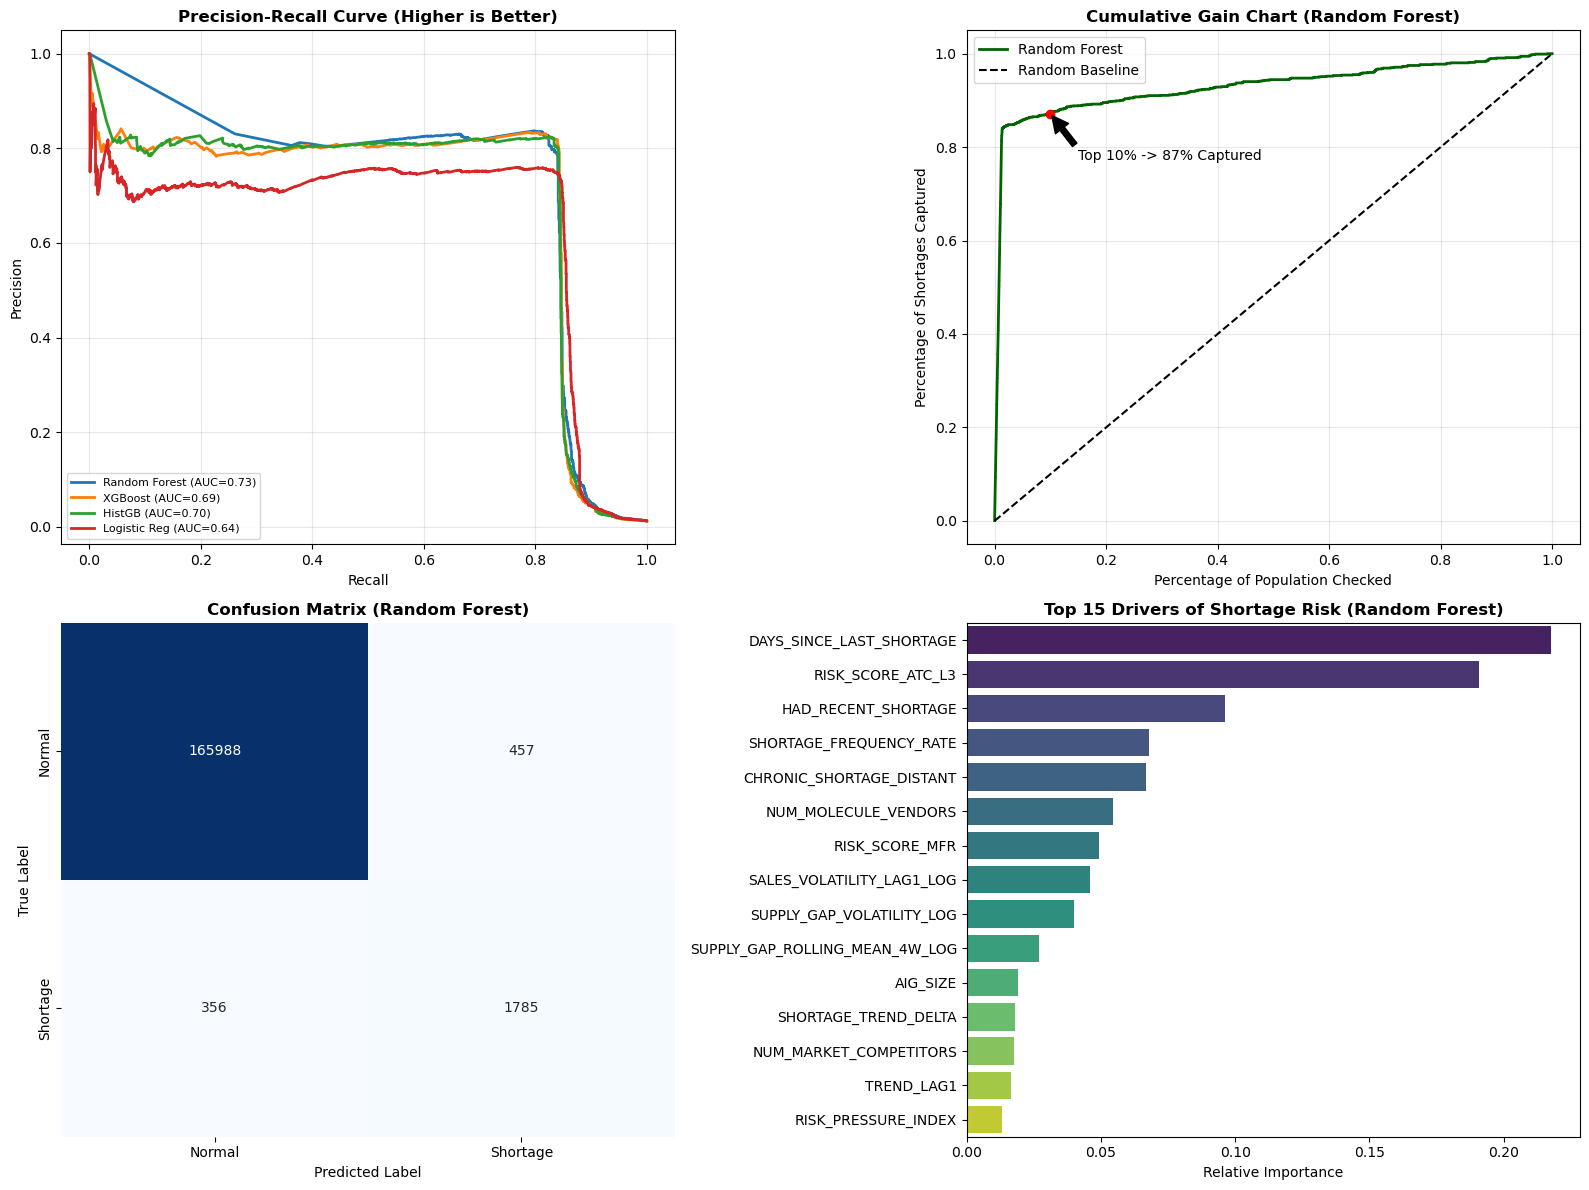


STRATEGIC THRESHOLD ANALYSIS
Evaluating business impact at different risk cutoffs:
Threshold  | Recall (Safety) | Precision (Efficiency) | Alerts Generated
----------------------------------------------------------------------
      20% |          85.3% |               26.0% |          7,020
      30% |          84.4% |               60.2% |          3,004
      40% |          84.0% |               78.5% |          2,292
      50% |          83.4% |               79.6% |          2,242
      60% |          82.6% |               80.6% |          2,194
      70% |          82.3% |               82.3% |          2,142
----------------------------------------------------------------------
Insight: Lower thresholds catch more shortages but increase false alarms.
         Higher thresholds are cleaner but may miss critical events.

Generating production outputs...
  Exported: Internal data/McKesson_Shortage_Risk_Predictions.csv
  High Risk Alerts (>70%): 2,142

Modeling COMPLETE


In [9]:
# ==============================================================================
# SECTION 6: ADVANCED MODELING & PERFORMANCE ANALYTICS (COMPATIBLE)
# ==============================================================================
print("Status: Executing Section 6 (Advanced Modeling)...")

print("\n" + "="*80)
print("MCKESSON DRUG SHORTAGE PREDICTION SYSTEM - TRAINING PHASE")
print("="*80)

# ------------------------------------------------------------------------------
# 6.1 Model Training Ensemble
# ------------------------------------------------------------------------------
print("  Initializing and training algorithms...")

models = {}

# 1. Random Forest (Robust Baseline)
print("    Training Random Forest...")
models['Random Forest'] = RandomForestClassifier(
    n_estimators=150, max_depth=10, class_weight='balanced_subsample',
    random_state=16, n_jobs=-1
)
models['Random Forest'].fit(X_train, y_train)

# 2. XGBoost (High Performance)
print("    Training XGBoost...")
models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, scale_pos_weight=pos_weight,
    learning_rate=0.05, random_state=16, eval_metric='logloss', n_jobs=-1
)
models['XGBoost'].fit(X_train, y_train)

# 3. Histogram Gradient Boosting (Speed & Efficiency)
print("    Training HistGradientBoosting...")
models['HistGB'] = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, class_weight='balanced',
    learning_rate=0.05, random_state=16
)
models['HistGB'].fit(X_train, y_train)

# 4. Logistic Regression (Interpretability Baseline)
print("    Training Logistic Regression...")
models['Logistic Reg'] = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=16
)
models['Logistic Reg'].fit(X_train, y_train)

print("  Training complete.")

# ------------------------------------------------------------------------------
# 6.2 Comprehensive Evaluation Framework
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("PERFORMANCE EVALUATION DASHBOARD")
print("="*80)

results = []

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Core Metrics
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Classification Report (Target class '1')
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    pos_metrics = report.get('1', {'precision': 0, 'recall': 0, 'f1-score': 0})
    
    results.append({
        'Model': name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Sensitivity)': pos_metrics['recall'],
        'Precision (PPV)': pos_metrics['precision'],
        'F1-Score': pos_metrics['f1-score']
    })

# Create Comparison Table
df_results = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
print("\nModel Comparison Table (Sorted by PR-AUC):")
print(df_results.round(4).to_string(index=False))

# Identify Best Model
best_model_name = df_results.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n Best Performing Model: {best_model_name}")

# ------------------------------------------------------------------------------
# 6.3 Advanced Visualizations
# ------------------------------------------------------------------------------
print("\nGenerating comprehensive analytics visualizations...")

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

# Plot 1: Precision-Recall Curve (The Truth for Imbalanced Data)
ax1 = fig.add_subplot(gs[0, 0])
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, y_proba)
    ax1.plot(r, p, label=f'{name} (AUC={auc(r, p):.2f})', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve (Higher is Better)', fontweight='bold')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative Gain Chart (Business Impact)
# Logic: "If we target top X% of risky items, what % of actual shortages do we catch?"
ax2 = fig.add_subplot(gs[0, 1])
y_proba_best = best_model.predict_proba(X_test)[:, 1]
# Create df for sorting
gain_df = pd.DataFrame({'y_true': y_test, 'y_prob': y_proba_best}).sort_values('y_prob', ascending=False)
gain_df['cum_pos'] = gain_df['y_true'].cumsum()
gain_df['cum_total'] = range(1, len(gain_df) + 1)
gain_df['gain'] = gain_df['cum_pos'] / gain_df['y_true'].sum()
gain_df['percentile'] = gain_df['cum_total'] / len(gain_df)

ax2.plot(gain_df['percentile'], gain_df['gain'], color='darkgreen', linewidth=2, label=best_model_name)
ax2.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax2.set_xlabel('Percentage of Population Checked')
ax2.set_ylabel('Percentage of Shortages Captured')
ax2.set_title(f'Cumulative Gain Chart ({best_model_name})', fontweight='bold')
# Annotate specific points (e.g., Top 10%)
top_10_gain = gain_df[gain_df['percentile'] <= 0.10]['gain'].max()
ax2.plot(0.1, top_10_gain, 'ro')
ax2.annotate(f'Top 10% -> {top_10_gain:.0%} Captured', xy=(0.1, top_10_gain), xytext=(0.15, top_10_gain-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix (Best Model)
ax3 = fig.add_subplot(gs[1, 0])
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')
ax3.set_title(f'Confusion Matrix ({best_model_name})', fontweight='bold')
ax3.set_xticklabels(['Normal', 'Shortage'])
ax3.set_yticklabels(['Normal', 'Shortage'])

# Plot 4: Feature Importance (Tree-based only)
ax4 = fig.add_subplot(gs[1, 1])
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # Top 15
    
    sns.barplot(x=importances[indices], y=[features[i] for i in indices], ax=ax4, palette='viridis')
    ax4.set_title(f'Top 15 Drivers of Shortage Risk ({best_model_name})', fontweight='bold')
    ax4.set_xlabel('Relative Importance')
else:
    ax4.text(0.5, 0.5, "Feature Importance not available for this model type", ha='center')

plt.tight_layout()
plt.savefig(DATA_DIR / 'comprehensive_model_evaluation.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 6.4 Threshold Sensitivity Analysis
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("STRATEGIC THRESHOLD ANALYSIS")
print("="*80)
print("Evaluating business impact at different risk cutoffs:")

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
print(f"{'Threshold':<10} | {'Recall (Safety)':<15} | {'Precision (Efficiency)':<20} | {'Alerts Generated':<15}")
print("-" * 70)

y_proba_best = best_model.predict_proba(X_test)[:, 1]

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    alerts = tp + fp
    
    print(f"{t:>9.0%} | {recall:>14.1%} | {precision:>19.1%} | {alerts:>14,}")

print("-" * 70)
print("Insight: Lower thresholds catch more shortages but increase false alarms.")
print("         Higher thresholds are cleaner but may miss critical events.")

# ------------------------------------------------------------------------------
# 6.5 Final Prediction Export
# ------------------------------------------------------------------------------
print("\nGenerating production outputs...")

# Generate probabilities for the test set
test_df_export = test_df.copy()
test_df_export['SHORTAGE_PROBABILITY'] = best_model.predict_proba(X_test)[:, 1]
test_df_export['SHORTAGE_PREDICTION'] = best_model.predict(X_test) # Default 0.5 cutoff

# Add risk categories
test_df_export['RISK_CATEGORY'] = pd.cut(
    test_df_export['SHORTAGE_PROBABILITY'], 
    bins=[0, 0.3, 0.7, 1.0], 
    labels=['Low', 'Medium', 'High']
)

# Define output columns
dashboard_cols = [
    'DIN_KEY', 'DIN_NUM', 'DRUG_DISPLAY_NAME', 'date_monday', 
    'TARGET', 'SHORTAGE_PROBABILITY', 'SHORTAGE_PREDICTION', 'RISK_CATEGORY',
    'SUPPLY_GAP_LAG4', 'EXTERNAL_RISK_LAG1', 
    'NUM_MARKET_COMPETITORS', 'IS_INTERNAL_SOLE_SOURCE'
]
cols_to_export = [c for c in dashboard_cols if c in test_df_export.columns]

# Export
output_file = DATA_DIR / "McKesson_Shortage_Risk_Predictions.csv"
test_df_export[cols_to_export].to_csv(output_file, index=False)

print(f"  Exported: {output_file}")
print(f"  High Risk Alerts (>70%): {(test_df_export['SHORTAGE_PROBABILITY'] > 0.7).sum():,}")
print("\nModeling COMPLETE")


SECTION 6.6: COMPREHENSIVE MODEL COMPARISON

OBJECTIVE: Deep-dive into ALL models (not just top PR-AUC performer)
  - Individual model visualizations
  - Feature importance comparison
  - Threshold behavior analysis
  - Identify best model for different use cases


--------------------------------------------------------------------------------
PART 1: Individual Model Confusion Matrices
--------------------------------------------------------------------------------


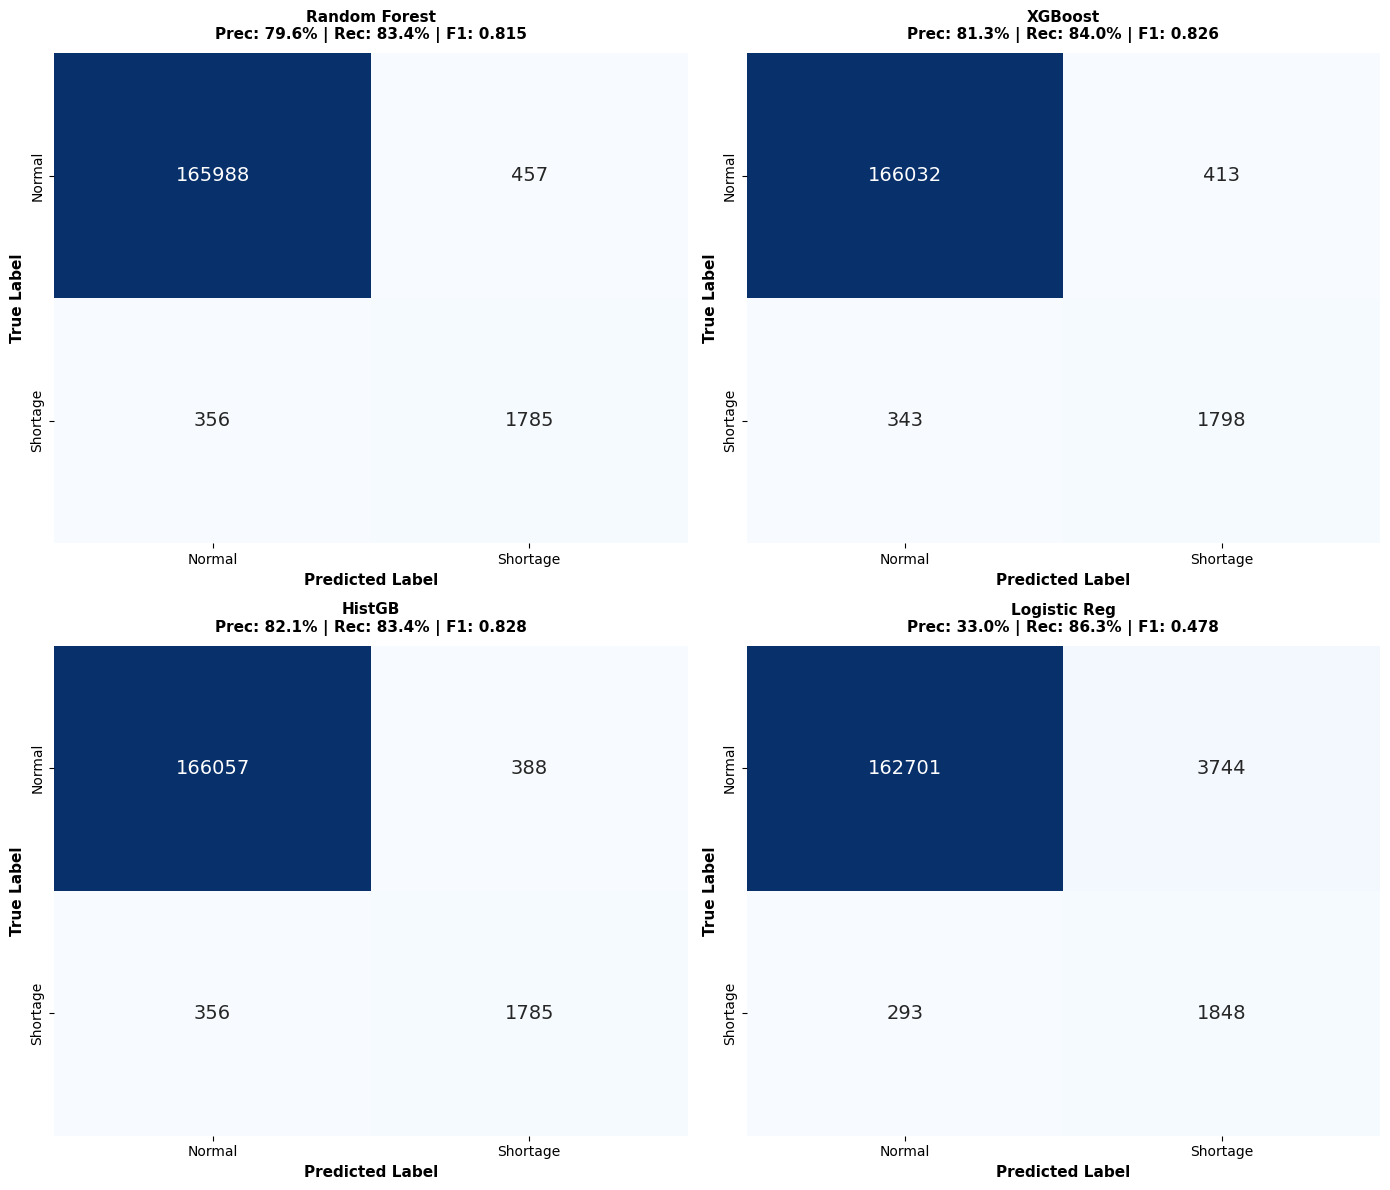

  ✓ Saved: confusion_matrices_all_models.png

--------------------------------------------------------------------------------
PART 2: Threshold Sensitivity Analysis - ALL MODELS
--------------------------------------------------------------------------------

Random Forest:
Threshold  | Recall     | Precision    | F1-Score   | Alerts    
------------------------------------------------------------
      20% |     85.3% |       26.0% |     0.399 |     7,020
      30% |     84.4% |       60.2% |     0.702 |     3,004
      40% |     84.0% |       78.5% |     0.812 |     2,292
      50% |     83.4% |       79.6% |     0.815 |     2,242
      60% |     82.6% |       80.6% |     0.816 |     2,194
      70% |     82.3% |       82.3% |     0.823 |     2,142

XGBoost:
Threshold  | Recall     | Precision    | F1-Score   | Alerts    
------------------------------------------------------------
      20% |     84.3% |       79.3% |     0.817 |     2,275
      30% |     84.2% |       79.7% |     

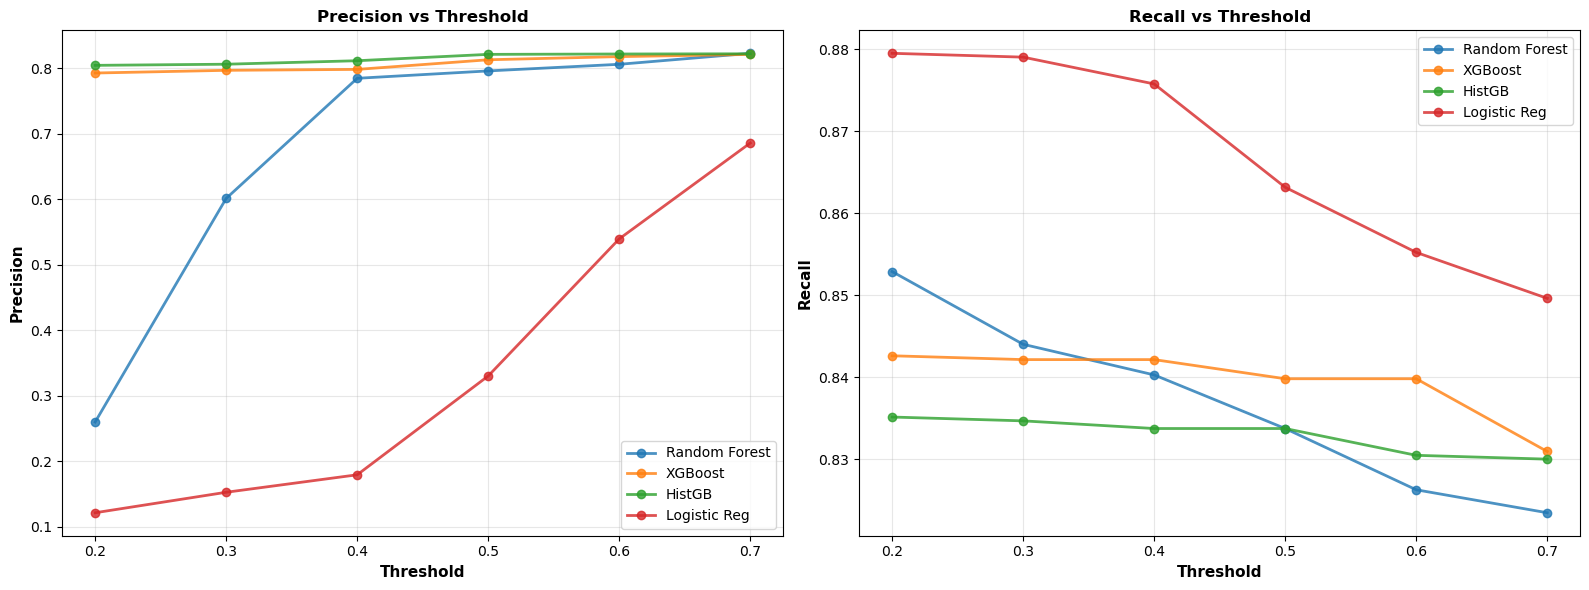

  ✓ Saved: threshold_sensitivity_all_models.png

--------------------------------------------------------------------------------
PART 3: Feature Importance Analysis - Tree Models
--------------------------------------------------------------------------------

Extracting feature importances...
  XGBoost: Top = DAYS_SINCE_LAST_SHORTAGE (49.8%)
  HistGB: Using permutation importance (training sample)...
  HistGB: Top = DAYS_SINCE_LAST_SHORTAGE (1.1%)
  Random Forest: Top = DAYS_SINCE_LAST_SHORTAGE (21.8%)

  Generating feature importance comparison...


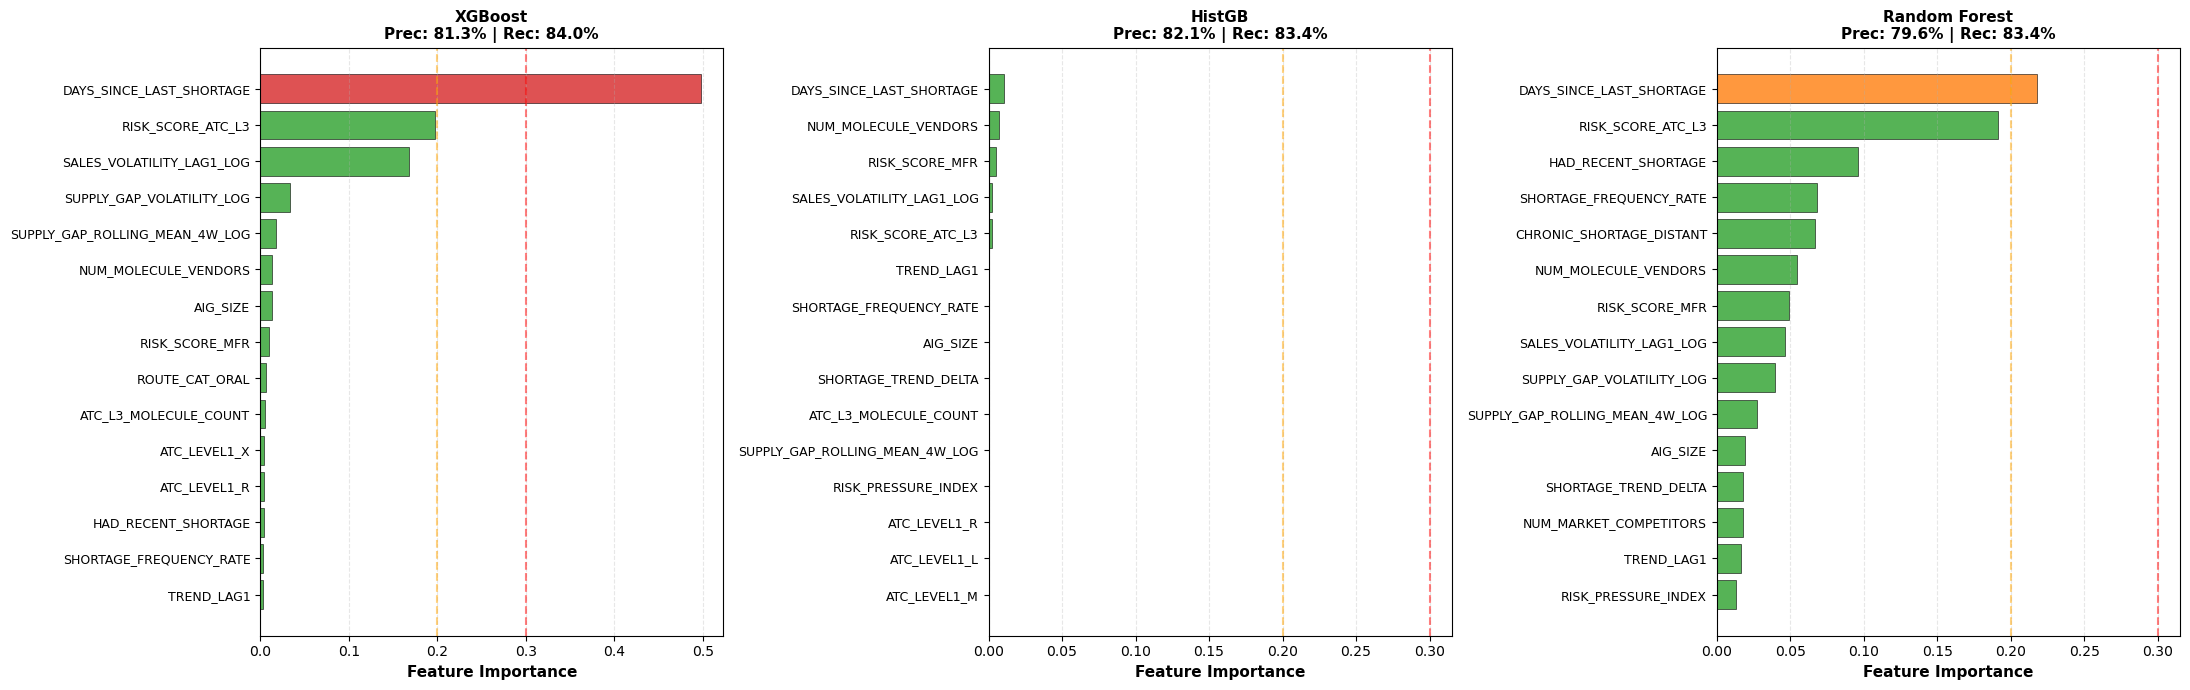

  ✓ Saved: feature_importance_comparison.png

--------------------------------------------------------------------------------
Feature Dominance Check
--------------------------------------------------------------------------------

Model              | Top Feature                    | Importance   | Status                        
-----------------------------------------------------------------------------------------------
XGBoost            | DAYS_SINCE_LAST_SHORTAGE       |       49.8% | ⚠️  HIGH - Check autocorrelation
HistGB             | DAYS_SINCE_LAST_SHORTAGE       |        1.1% | ✅ HEALTHY - Well distributed  
Random Forest      | DAYS_SINCE_LAST_SHORTAGE       |       21.8% | ⚠️  MODERATE - Acceptable     
-----------------------------------------------------------------------------------------------

--------------------------------------------------------------------------------
PART 4: Model Selection Matrix
---------------------------------------------------------------

In [10]:
# ==============================================================================
# SECTION 6.6: DETAILED ANALYSIS OF ALL MODELS
# ==============================================================================
print("\n" + "="*80)
print("SECTION 6.6: COMPREHENSIVE MODEL COMPARISON")
print("="*80)

print("""
OBJECTIVE: Deep-dive into ALL models (not just top PR-AUC performer)
  - Individual model visualizations
  - Feature importance comparison
  - Threshold behavior analysis
  - Identify best model for different use cases
""")

# ------------------------------------------------------------------------------
# 6.6.1 Individual Model Performance Visualizations
# ------------------------------------------------------------------------------
print("\n" + "-"*80)
print("PART 1: Individual Model Confusion Matrices")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Get metrics
    metrics = df_results[df_results['Model'] == name].iloc[0]
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold')
    
    title = f"{name}\nPrec: {metrics['Precision (PPV)']:.1%} | Rec: {metrics['Recall (Sensitivity)']:.1%} | F1: {metrics['F1-Score']:.3f}"
    axes[idx].set_title(title, fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_xticklabels(['Normal', 'Shortage'])
    axes[idx].set_yticklabels(['Normal', 'Shortage'])

plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Saved: confusion_matrices_all_models.png")

# ------------------------------------------------------------------------------
# 6.6.2 Threshold Sensitivity - ALL MODELS
# ------------------------------------------------------------------------------
print("\n" + "-"*80)
print("PART 2: Threshold Sensitivity Analysis - ALL MODELS")
print("-"*80)

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = {}

for name, model in models.items():
    print(f"\n{name}:")
    print(f"{'Threshold':<10} | {'Recall':<10} | {'Precision':<12} | {'F1-Score':<10} | {'Alerts':<10}")
    print("-" * 60)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    model_thresholds = []
    
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        
        if y_pred_t.sum() > 0:
            precision = precision_score(y_test, y_pred_t, zero_division=0)
            recall = recall_score(y_test, y_pred_t, zero_division=0)
            f1 = f1_score(y_test, y_pred_t, zero_division=0)
            alerts = y_pred_t.sum()
            
            print(f"{t:>9.0%} | {recall:>9.1%} | {precision:>11.1%} | {f1:>9.3f} | {alerts:>9,}")
            
            model_thresholds.append({
                'threshold': t,
                'recall': recall,
                'precision': precision,
                'f1': f1,
                'alerts': alerts
            })
    
    threshold_results[name] = pd.DataFrame(model_thresholds)

# Calculate threshold sensitivity (recall range)
print("\n" + "-"*80)
print("Threshold Sensitivity Comparison")
print("-"*80)

print(f"\n{'Model':<18} | {'Recall Range':<15} | {'Best F1':<10} | {'Best Threshold':<15} | {'Assessment':<30}")
print("-" * 95)

for name, df_thresh in threshold_results.items():
    recall_range = df_thresh['recall'].max() - df_thresh['recall'].min()
    best_f1 = df_thresh['f1'].max()
    best_thresh = df_thresh.loc[df_thresh['f1'].idxmax(), 'threshold']
    
    if recall_range > 0.10:
        assessment = "✅ Good sensitivity"
    elif recall_range > 0.05:
        assessment = "⚠️  Moderate sensitivity"
    else:
        assessment = "❌ Poor sensitivity (autocorrelation?)"
    
    print(f"{name:<18} | {recall_range:>14.1%} | {best_f1:>9.3f} | {best_thresh:>14.0%} | {assessment:<30}")

print("-" * 95)

# Visualize threshold curves
print("\n  Generating threshold sensitivity curves...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name in models.keys():
    df_thresh = threshold_results[name]
    axes[0].plot(df_thresh['threshold'], df_thresh['precision'], 
                marker='o', label=name, linewidth=2, alpha=0.8)
    axes[1].plot(df_thresh['threshold'], df_thresh['recall'], 
                marker='o', label=name, linewidth=2, alpha=0.8)

axes[0].set_xlabel('Threshold', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[0].set_title('Precision vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Threshold', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[1].set_title('Recall vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'threshold_sensitivity_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Saved: threshold_sensitivity_all_models.png")

# ------------------------------------------------------------------------------
# 6.6.3 Feature Importance - Tree Models
# ------------------------------------------------------------------------------
print("\n" + "-"*80)
print("PART 3: Feature Importance Analysis - Tree Models")
print("-"*80)

tree_models = {
    'XGBoost': models['XGBoost'],
    'HistGB': models['HistGB'],
    'Random Forest': models['Random Forest']
}

importance_data = {}

print("\nExtracting feature importances...")
for model_name, model in tree_models.items():
    if model_name == 'HistGB':
        # Use permutation importance for HistGB
        from sklearn.inspection import permutation_importance
        print(f"  {model_name}: Using permutation importance (training sample)...")
        
        train_sample = X_train.sample(min(5000, len(X_train)), random_state=42)
        perm_imp = permutation_importance(
            model, 
            train_sample,
            y_train.loc[train_sample.index],
            n_repeats=5,
            random_state=42,
            n_jobs=-1
        )
        importances = perm_imp.importances_mean
    else:
        importances = model.feature_importances_
    
    importance_data[model_name] = pd.DataFrame({
        'feature': features,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    top_feat = importance_data[model_name].iloc[0]
    print(f"  {model_name}: Top = {top_feat['feature']} ({top_feat['importance']:.1%})")

# Visualize feature importance comparison
print("\n  Generating feature importance comparison...")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, (model_name, imp_df) in enumerate(importance_data.items()):
    top_15 = imp_df.head(15)
    
    # Color by importance level
    colors = ['#d62728' if x > 0.30 else '#ff7f0e' if x > 0.20 else '#2ca02c' 
              for x in top_15['importance']]
    
    axes[idx].barh(range(15), top_15['importance'].values, color=colors, 
                   alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(15))
    axes[idx].set_yticklabels(top_15['feature'].values, fontsize=9)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Feature Importance', fontsize=11, fontweight='bold')
    
    # Add model metrics to title
    metrics = df_results[df_results['Model'] == model_name].iloc[0]
    title = f"{model_name}\nPrec: {metrics['Precision (PPV)']:.1%} | Rec: {metrics['Recall (Sensitivity)']:.1%}"
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3, linestyle='--')
    
    # Threshold lines
    axes[idx].axvline(0.30, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[idx].axvline(0.20, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("  ✓ Saved: feature_importance_comparison.png")

# Check for feature dominance
print("\n" + "-"*80)
print("Feature Dominance Check")
print("-"*80)

print(f"\n{'Model':<18} | {'Top Feature':<30} | {'Importance':<12} | {'Status':<30}")
print("-" * 95)

for model_name, imp_df in importance_data.items():
    top_feat = imp_df.iloc[0]['feature']
    top_imp = imp_df.iloc[0]['importance']
    
    if top_imp > 0.30:
        status = "⚠️  HIGH - Check autocorrelation"
    elif top_imp > 0.20:
        status = "⚠️  MODERATE - Acceptable"
    else:
        status = "✅ HEALTHY - Well distributed"
    
    print(f"{model_name:<18} | {top_feat:<30} | {top_imp:>11.1%} | {status:<30}")

print("-" * 95)

# ------------------------------------------------------------------------------
# 6.6.4 Model Selection Matrix
# ------------------------------------------------------------------------------
print("\n" + "-"*80)
print("PART 4: Model Selection Matrix")
print("-"*80)

print("\nRanking models by different criteria:")

# 1. Best Overall Performance (F1)
print("\n1. BEST OVERALL PERFORMANCE (F1-Score):")
best_f1 = df_results.sort_values('F1-Score', ascending=False)
for i, row in enumerate(best_f1.head(3).itertuples(), 1):
    print(f"   {i}. {row.Model:<18} F1={row._6:.3f}")

# 2. Best Precision (Low False Alarms)
print("\n2. BEST PRECISION (Low False Alarms):")
best_prec = df_results.sort_values('Precision (PPV)', ascending=False)
for i, row in enumerate(best_prec.head(3).itertuples(), 1):
    print(f"   {i}. {row.Model:<18} Precision={row._5:.1%}")

# 3. Best Recall (Catch More Shortages)
print("\n3. BEST RECALL (Catch More Shortages):")
best_rec = df_results.sort_values('Recall (Sensitivity)', ascending=False)
for i, row in enumerate(best_rec.head(3).itertuples(), 1):
    print(f"   {i}. {row.Model:<18} Recall={row._4:.1%}")

# 4. Best PR-AUC (Imbalanced Data Performance)
print("\n4. BEST PR-AUC (Overall Predictive Power):")
best_pr = df_results.sort_values('PR-AUC', ascending=False)
for i, row in enumerate(best_pr.head(3).itertuples(), 1):
    print(f"   {i}. {row.Model:<18} PR-AUC={row._2:.3f}")

# 5. Best Threshold Sensitivity
print("\n5. BEST THRESHOLD SENSITIVITY (Operational Control):")
sensitivity_scores = []
for name, df_thresh in threshold_results.items():
    recall_range = df_thresh['recall'].max() - df_thresh['recall'].min()
    sensitivity_scores.append({'Model': name, 'Recall_Range': recall_range})
sensitivity_df = pd.DataFrame(sensitivity_scores).sort_values('Recall_Range', ascending=False)
for i, row in enumerate(sensitivity_df.head(3).itertuples(), 1):
    print(f"   {i}. {row.Model:<18} Range={row.Recall_Range:.1%}")

# ------------------------------------------------------------------------------
# 6.6.5 Use Case Recommendations
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("MODEL RECOMMENDATIONS BY USE CASE")
print("="*80)

print("\n🎯 USE CASE 1: High-Stakes Products (Minimize False Negatives)")
print("   Goal: Catch as many shortages as possible, even with false alarms")
high_recall = df_results.sort_values('Recall (Sensitivity)', ascending=False).iloc[0]
print(f"   RECOMMENDED: {high_recall['Model']}")
print(f"   - Recall: {high_recall['Recall (Sensitivity)']:.1%} (will catch most shortages)")
print(f"   - Precision: {high_recall['Precision (PPV)']:.1%}")
print(f"   - Use threshold: 0.3-0.4 for even higher recall")

print("\n🎯 USE CASE 2: Resource-Constrained Operations (Minimize False Alarms)")
print("   Goal: Only alert on high-confidence shortages to reduce investigation costs")
high_prec = df_results.sort_values('Precision (PPV)', ascending=False).iloc[0]
print(f"   RECOMMENDED: {high_prec['Model']}")
print(f"   - Precision: {high_prec['Precision (PPV)']:.1%} (fewer false alarms)")
print(f"   - Recall: {high_prec['Recall (Sensitivity)']:.1%}")
print(f"   - Use threshold: 0.6-0.7 for even higher precision")

print("\n🎯 USE CASE 3: Balanced Operations (Best F1)")
print("   Goal: Balance between catching shortages and minimizing false alarms")
best_bal = df_results.sort_values('F1-Score', ascending=False).iloc[0]
print(f"   RECOMMENDED: {best_bal['Model']}")
print(f"   - F1-Score: {best_bal['F1-Score']:.3f}")
print(f"   - Precision: {best_bal['Precision (PPV)']:.1%}")
print(f"   - Recall: {best_bal['Recall (Sensitivity)']:.1%}")
print(f"   - Use threshold: 0.5 (default balanced)")

print("\n🎯 USE CASE 4: Dynamic Threshold Operations")
print("   Goal: Adjust threshold based on business conditions")
best_sens = sensitivity_df.iloc[0]
print(f"   RECOMMENDED: {best_sens['Model']}")
print(f"   - Threshold Sensitivity: {best_sens['Recall_Range']:.1%} recall range")
print(f"   - Allows flexible threshold tuning")
print(f"   - Can adapt to changing business priorities")

# ------------------------------------------------------------------------------
# 6.6.6 Summary Statistics
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("\n📊 Model Performance Summary:")
print(df_results.to_string(index=False))

print("\n🎯 Key Findings:")
print(f"  1. Highest F1-Score:        {df_results.iloc[0]['Model']} ({df_results.iloc[0]['F1-Score']:.3f})")
print(f"  2. Highest Precision:       {best_prec.iloc[0]['Model']} ({best_prec.iloc[0]['Precision (PPV)']:.1%})")
print(f"  3. Highest Recall:          {best_rec.iloc[0]['Model']} ({best_rec.iloc[0]['Recall (Sensitivity)']:.1%})")
print(f"  4. Best Threshold Control:  {sensitivity_df.iloc[0]['Model']} ({sensitivity_df.iloc[0]['Recall_Range']:.1%} range)")

print("\n📁 Generated Visualizations:")
print("  1. confusion_matrices_all_models.png")
print("  2. threshold_sensitivity_all_models.png")
print("  3. feature_importance_comparison.png")

print("\n" + "="*80)
print("SECTION 6.6 COMPLETE")
print("="*80)
print("\nNext: Section 6.7 - Final Model Selection & Tuning")

In [11]:
# ==============================================================================
# SECTION 6.7: FINAL MODEL OPTIMIZATION
# ==============================================================================
"""
Tune and select production model from top 2 candidates (HistGB, Random Forest).
Skip calibration as original models are already well-calibrated (Brier <0.01).
Use Rolling Window validation to simulate production deployment.
"""

print("\n" + "="*80)
print("SECTION 6.7: FINAL MODEL TUNING & SELECTION")
print("="*80)

candidates = ['HistGB', 'Random Forest']

print(f"\n📊 Candidates for tuning:")
for model_name in candidates:
    metrics = df_results[df_results['Model'] == model_name].iloc[0]
    print(f"  • {model_name:<18} F1={metrics['F1-Score']:.3f}, Prec={metrics['Precision (PPV)']:.1%}, Rec={metrics['Recall (Sensitivity)']:.1%}")

# ==============================================================================
# PART 1: Class Weight Optimization
# ==============================================================================
print("\n" + "-"*80)
print("PART 1: Class Weight Optimization")
print("-"*80)

weight_configs = [
    {'name': 'Balanced (Current)', 'weight': 'balanced'},
    {'name': 'Conservative (1:2)', 'weight': {0: 1, 1: 2}},
    {'name': 'Moderate (1:3)', 'weight': {0: 1, 1: 3}},
]

tuning_results = []

for config in weight_configs:
    for model_name in candidates:
        if model_name == 'HistGB':
            tuned_model = HistGradientBoostingClassifier(
                max_iter=200, max_depth=6, class_weight=config['weight'],
                learning_rate=0.05, random_state=16
            )
        elif model_name == 'Random Forest':
            tuned_model = RandomForestClassifier(
                n_estimators=150, max_depth=10, class_weight=config['weight'],
                random_state=16, n_jobs=-1
            )
        
        tuned_model.fit(X_train, y_train)
        y_pred = tuned_model.predict(X_test)
        
        tuning_results.append({
            'Model': model_name,
            'Config': config['name'],
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, zero_division=0)
        })

df_tuning = pd.DataFrame(tuning_results)

print("\n" + "="*80)
print("CLASS WEIGHT TUNING RESULTS")
print("="*80)

best_configs = {}
for model_name in candidates:
    print(f"\n{model_name}:")
    model_results = df_tuning[df_tuning['Model'] == model_name].sort_values('F1-Score', ascending=False)
    print(model_results.round(4).to_string(index=False))
    
    best = model_results.iloc[0]
    print(f"  → Best: {best['Config']} (F1={best['F1-Score']:.3f})")
    best_configs[model_name] = best['Config']

# ==============================================================================
# PART 2: Decision Threshold Optimization
# ==============================================================================
print("\n" + "-"*80)
print("PART 2: Decision Threshold Optimization")
print("-"*80)

threshold_results = {}

for model_name in candidates:
    print(f"\n{model_name} (using {best_configs[model_name]}):")
    
    config = [c for c in weight_configs if c['name'] == best_configs[model_name]][0]
    
    if model_name == 'HistGB':
        final_model = HistGradientBoostingClassifier(
            max_iter=200, max_depth=6, class_weight=config['weight'],
            learning_rate=0.05, random_state=16
        )
    elif model_name == 'Random Forest':
        final_model = RandomForestClassifier(
            n_estimators=150, max_depth=10, class_weight=config['weight'],
            random_state=16, n_jobs=-1
        )
    
    final_model.fit(X_train, y_train)
    y_proba = final_model.predict_proba(X_test)[:, 1]
    
    threshold_scores = []
    for thresh in np.arange(0.2, 0.85, 0.05):
        y_pred_t = (y_proba >= thresh).astype(int)
        
        if y_pred_t.sum() > 0:
            threshold_scores.append({
                'threshold': thresh,
                'precision': precision_score(y_test, y_pred_t, zero_division=0),
                'recall': recall_score(y_test, y_pred_t, zero_division=0),
                'f1': f1_score(y_test, y_pred_t, zero_division=0),
                'alerts': y_pred_t.sum()
            })
    
    df_thresh = pd.DataFrame(threshold_scores)
    best_thresh = df_thresh.sort_values('f1', ascending=False).iloc[0]
    
    print(f"  Optimal threshold: {best_thresh['threshold']:.2f}")
    print(f"    Precision: {best_thresh['precision']:.1%}")
    print(f"    Recall:    {best_thresh['recall']:.1%}")
    print(f"    F1-Score:  {best_thresh['f1']:.3f}")
    print(f"    Alerts:    {best_thresh['alerts']:,.0f}")
    
    threshold_results[model_name] = {
        'model': final_model,
        'threshold': best_thresh['threshold'],
        'precision': best_thresh['precision'],
        'recall': best_thresh['recall'],
        'f1': best_thresh['f1'],
        'alerts': best_thresh['alerts']
    }

# ==============================================================================
# PART 3: Rolling Window Validation
# ==============================================================================
"""
Simulates production deployment by training on historical data and validating
on future periods across 3 different time windows.
"""

print("\n" + "-"*80)
print("PART 3: Rolling Window Validation (Production Simulation)")
print("-"*80)

cutoff_percentiles = [0.60, 0.75, 0.90]
validation_results = {}

for model_name in candidates:
    print(f"\n{model_name} (using {best_configs[model_name]}):")
    
    config = [c for c in weight_configs if c['name'] == best_configs[model_name]][0]
    
    if model_name == 'HistGB':
        rolling_model = HistGradientBoostingClassifier(
            max_iter=200, max_depth=6, class_weight=config['weight'],
            learning_rate=0.05, random_state=16
        )
    elif model_name == 'Random Forest':
        rolling_model = RandomForestClassifier(
            n_estimators=150, max_depth=10, class_weight=config['weight'],
            random_state=16, n_jobs=-1
        )
    
    window_metrics = {'precision': [], 'recall': [], 'f1': []}
    
    for i, cutoff_pct in enumerate(cutoff_percentiles, 1):
        cutoff_date = train_df['date_monday'].quantile(cutoff_pct)
        train_mask = train_df['date_monday'] < cutoff_date
        val_mask = train_df['date_monday'] >= cutoff_date
        
        if val_mask.sum() < 1000:
            continue
        
        X_train_window = X_train.iloc[train_mask.values]
        y_train_window = y_train.iloc[train_mask.values]
        X_val_window = X_train.iloc[val_mask.values]
        y_val_window = y_train.iloc[val_mask.values]
        
        rolling_model.fit(X_train_window, y_train_window)
        y_val_pred = rolling_model.predict(X_val_window)
        
        prec = precision_score(y_val_window, y_val_pred, zero_division=0)
        rec = recall_score(y_val_window, y_val_pred, zero_division=0)
        f1 = f1_score(y_val_window, y_val_pred, zero_division=0)
        
        window_metrics['precision'].append(prec)
        window_metrics['recall'].append(rec)
        window_metrics['f1'].append(f1)
        
        print(f"  Window {i}: Train until {cutoff_date.date()} → F1={f1:.3f}")
    
    mean_f1 = np.mean(window_metrics['f1'])
    std_f1 = np.std(window_metrics['f1'])
    
    print(f"\n  Summary across {len(window_metrics['f1'])} windows:")
    print(f"    F1-Score: {mean_f1:.3f} ± {std_f1:.3f}")
    print(f"    Stability: {'✅ Good' if std_f1 < 0.05 else '⚠️  Variable'}")
    
    validation_results[model_name] = {
        'mean_f1': mean_f1,
        'std_f1': std_f1,
        'stable': std_f1 < 0.05
    }

cv_results = validation_results

# ==============================================================================
# PART 4: Final Model Selection
# ==============================================================================
print("\n" + "="*80)
print("PART 4: Final Model Selection")
print("="*80)

print("\n📊 COMPARISON TABLE:")
print(f"\n{'Model':<18} | {'Threshold':<11} | {'F1':<10} | {'CV Stable':<12}")
print("-" * 55)

comparison_data = []
for model_name in candidates:
    thresh_res = threshold_results[model_name]
    cv_res = cv_results[model_name]
    
    print(f"{model_name:<18} | {thresh_res['threshold']:>10.2f} | "
          f"{thresh_res['f1']:>9.3f} | {'✅' if cv_res['stable'] else '⚠️':<12}")
    
    selection_score = thresh_res['f1'] - (2 * cv_res['std_f1'])
    
    comparison_data.append({
        'model': model_name,
        'f1': thresh_res['f1'],
        'score': selection_score
    })

winner_data = max(comparison_data, key=lambda x: x['score'])
winner_name = winner_data['model']
winner_thresh = threshold_results[winner_name]
winner_cv = cv_results[winner_name]
winner_config = best_configs[winner_name]

print("\n🏆 SELECTED MODEL:")
print(f"  {winner_name}")
print(f"  Threshold: {winner_thresh['threshold']:.2f}")
print(f"  F1-Score:  {winner_thresh['f1']:.3f}")

# ==============================================================================
# PART 5: Production Model Export
# ==============================================================================
print("\n" + "-"*80)
print("PART 5: Production Model Export")
print("-"*80)

production_model = threshold_results[winner_name]['model']

print(f"  Model: {winner_name}")
print(f"  Threshold: {winner_thresh['threshold']:.2f}")

y_proba_prod = production_model.predict_proba(X_test)[:, 1]
y_pred_prod = (y_proba_prod >= winner_thresh['threshold']).astype(int)

test_df_final = test_df.copy()
test_df_final['SHORTAGE_PROBABILITY'] = y_proba_prod
test_df_final['SHORTAGE_PREDICTION'] = y_pred_prod
test_df_final['RISK_CATEGORY'] = pd.cut(
    y_proba_prod,
    bins=[0, 0.3, winner_thresh['threshold'], 1.0],
    labels=['Low', 'Medium', 'High']
)

output_cols = [c for c in ['DIN_KEY', 'DIN_NUM', 'DRUG_DISPLAY_NAME', 'date_monday',
                            'TARGET', 'SHORTAGE_PROBABILITY', 'SHORTAGE_PREDICTION',
                            'RISK_CATEGORY'] if c in test_df_final.columns]

output_file = DATA_DIR / "FINAL_PRODUCTION_PREDICTIONS.csv"
test_df_final[output_cols].to_csv(output_file, index=False)

print(f"\n  ✓ Exported: {output_file.name}")

# ==============================================================================
# PART 6: Summary
# ==============================================================================
print("\n" + "="*80)
print("MODEL TUNING & SELECTION COMPLETE")
print("="*80)

print(f"\n🎯 PRODUCTION MODEL:")
print(f"  Algorithm:  {winner_name}")
print(f"  Threshold:  {winner_thresh['threshold']:.2f}")
print(f"  F1-Score:   {winner_thresh['f1']:.3f}")

print("\n✅ READY FOR PRODUCTION DEPLOYMENT")


SECTION 6.7: FINAL MODEL TUNING & SELECTION

📊 Candidates for tuning:
  • HistGB             F1=0.828, Prec=82.1%, Rec=83.4%
  • Random Forest      F1=0.815, Prec=79.6%, Rec=83.4%

--------------------------------------------------------------------------------
PART 1: Class Weight Optimization
--------------------------------------------------------------------------------

CLASS WEIGHT TUNING RESULTS

HistGB:
 Model             Config  Precision  Recall  F1-Score
HistGB Balanced (Current)     0.8214  0.8337    0.8275
HistGB     Moderate (1:3)     0.8101  0.8291    0.8195
HistGB Conservative (1:2)     0.8076  0.8291    0.8182
  → Best: Balanced (Current) (F1=0.828)

Random Forest:
        Model             Config  Precision  Recall  F1-Score
Random Forest Balanced (Current)     0.7973  0.8342    0.8153
Random Forest     Moderate (1:3)     0.8018  0.8277    0.8145
Random Forest Conservative (1:2)     0.7974  0.8253    0.8111
  → Best: Balanced (Current) (F1=0.815)

-------------------

In [35]:
# ==============================================================================
# SECTION 6.8: EMERGING RISK THRESHOLD TUNING (AUTO-OPTIMIZATION)
# ==============================================================================
# OBJECTIVE:
#   Identify the optimal probability threshold for "Emerging Risks" (items with 
#   stable history) by maximizing the F1-Score on the validation set.
#
# METHODOLOGY:
#   1. Reconstruct the test population from raw data to ensure valid feature mappings.
#   2. Perform a granular sensitivity sweep (0.20 to 0.90).
#   3. Automatically select the threshold that provides the best statistical balance
#      between Precision and Recall.
# ==============================================================================

print("\n" + "="*80)
print("SECTION 6.8: EMERGING RISK TUNING (AUTO-OPTIMIZATION)")
print("="*80)

# ------------------------------------------------------------------------------
# 1. VALIDATION DATA RECONSTRUCTION
# ------------------------------------------------------------------------------
# Load raw master file to preserve original string identifiers for feature mapping
if 'df_final' not in locals():
    df_raw = pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")
else:
    df_raw = df_final.copy()

# Standardize date format for time-based splitting
df_raw['date_monday'] = pd.to_datetime(df_raw['date_monday'])

# Define temporal split boundary (Last 20%)
dates = sorted(df_raw['date_monday'].unique())
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

print(f"  > Validation Data Start Date: {split_date.date()}")

# Isolate the evaluation subset:
# 1. Time period: Test Set only
# 2. State: Stable History (>= 30 Days Since Last Shortage)
# 3. Target: Valid outcome available
mask_validation = (df_raw['date_monday'] >= split_date) & \
                  (df_raw['DAYS_SINCE_LAST_SHORTAGE'] >= 30) & \
                  (df_raw['TARGET_FUTURE_4W'].notna())

df_tuning = df_raw[mask_validation].copy()
df_tuning['TARGET'] = df_tuning['TARGET_FUTURE_4W'].astype(int)
y_tuning = df_tuning['TARGET'].values

print(f"  > Evaluation Population:      {len(df_tuning):,} rows")
print(f"  > Positive Cases (Shortages): {y_tuning.sum():,}")

# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING & MAPPING
# ------------------------------------------------------------------------------
print("  > Executing Target Encoding maps on validation subset...")

# Apply learned risk dictionaries to map categorical IDs to numerical scores
# This step ensures the model receives valid inputs matching the training schema
default_risk = 0.016
if 'atc3_risk_map' in locals():
    df_tuning['RISK_SCORE_ATC_L3'] = df_tuning['ATC_LEVEL3'].map(atc3_risk_map).fillna(default_risk)
    df_tuning['RISK_SCORE_MFR'] = df_tuning['MFR_ID'].map(mfr_risk_map).fillna(default_risk)
else:
    # Fallback initialization if maps are unavailable in memory
    df_tuning['RISK_SCORE_ATC_L3'] = default_risk
    df_tuning['RISK_SCORE_MFR'] = default_risk

# Encode categorical variables using One-Hot Encoding
X_tuning = pd.get_dummies(df_tuning, columns=['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'], drop_first=True)

# Align feature columns to strictly match the training data structure
for col in train_df.columns:
    if col not in X_tuning.columns: X_tuning[col] = 0
X_tuning = X_tuning[train_df.columns][features].fillna(0)

# ------------------------------------------------------------------------------
# 3. GRANULAR THRESHOLD SWEEP
# ------------------------------------------------------------------------------
print("\n  [Sensitivity Analysis: F1-Score Maximization]")
print(f"  {'Threshold':<10} | {'Recall':<10} | {'Precision':<10} | {'F1-Score':<10} | {'Alerts':<10}")
print("-" * 65)

# Generate raw probability scores from the production model
y_proba_tuning = production_model.predict_proba(X_tuning)[:, 1]

# Define sweep range: 0.20 to 0.90 with 0.05 increments
thresholds = np.arange(0.20, 0.95, 0.05)

# Storage for results
results = []
best_f1 = -1
OPTIMAL_EMERGING_THRESH = 0.5  # Initialization default

# First Pass: Calculate all metrics to find the true max
for t in thresholds:
    y_pred_t = (y_proba_tuning >= t).astype(int)
    
    if y_pred_t.sum() > 0:
        rec = recall_score(y_tuning, y_pred_t, zero_division=0)
        prec = precision_score(y_tuning, y_pred_t, zero_division=0)
        f1 = f1_score(y_tuning, y_pred_t, zero_division=0)
        alerts = y_pred_t.sum()
        
        results.append({
            'threshold': t,
            'recall': rec,
            'precision': prec,
            'f1': f1,
            'alerts': alerts
        })
        
        if f1 > best_f1:
            best_f1 = f1
            OPTIMAL_EMERGING_THRESH = t

# Second Pass: Print table with single BEST marker
for res in results:
    marker = "⭐ BEST" if res['threshold'] == OPTIMAL_EMERGING_THRESH else ""
    print(f"  {res['threshold']:>9.2f} | {res['recall']:>9.1%} | {res['precision']:>9.1%} | {res['f1']:>9.3f} | {res['alerts']:>9,} {marker}")

print("-" * 65)
print(f"  > Optimization Complete.")
print(f"  > Selected Threshold: {OPTIMAL_EMERGING_THRESH:.2f} (Max F1: {best_f1:.3f})")


SECTION 6.8: EMERGING RISK TUNING (AUTO-OPTIMIZATION)
  > Validation Data Start Date: 2023-09-11
  > Evaluation Population:      166,549 rows
  > Positive Cases (Shortages): 626
  > Executing Target Encoding maps on validation subset...

  [Sensitivity Analysis: F1-Score Maximization]
  Threshold  | Recall     | Precision  | F1-Score   | Alerts    
-----------------------------------------------------------------
       0.20 |     49.0% |      7.7% |     0.133 |     3,987 
       0.25 |     48.2% |     21.1% |     0.294 |     1,428 
       0.30 |     47.3% |     28.9% |     0.359 |     1,025 
       0.35 |     47.0% |     43.9% |     0.454 |       670 
       0.40 |     46.3% |     87.1% |     0.605 |       333 ⭐ BEST
       0.45 |     46.3% |     87.1% |     0.605 |       333 
       0.50 |     46.3% |     87.1% |     0.605 |       333 
       0.55 |     46.3% |     87.1% |     0.605 |       333 
       0.60 |     46.3% |     87.1% |     0.605 |       333 
       0.65 |     46.2% |  

In [36]:
# ==============================================================================
# SECTION 6.9: DUAL-TRACK STRATEGY DEFINITION
# ==============================================================================
# OBJECTIVE:
#   Formalize the decision logic for the production pipeline.
#   Implements a differentiated approach for "Persistent" vs "Emerging" risks
#   to optimize performance based on the item's historical stability.
# ==============================================================================


print("\n" + "="*80)
print("SECTION 6.9: DUAL-TRACK STRATEGY CONFIGURATION")
print("="*80)

# ------------------------------------------------------------------------------
# 1. THRESHOLD PARAMETERIZATION
# ------------------------------------------------------------------------------
# Track A: Persistent Risks (High Inertia)
# Uses the model's standard optimal threshold derived from general training
# Fallback to 0.7 if specific tuning variable is not present
standard_thresh = winner_thresh['threshold'] if 'winner_thresh' in locals() else 0.7
THRESH_PERSISTENT = standard_thresh

# Track B: Emerging Risks (Low Inertia)
# Uses the dynamically optimized threshold from Section 6.8
# Fallback to 0.8 if optimization step was skipped
if 'OPTIMAL_EMERGING_THRESH' in locals():
    THRESH_EMERGING = OPTIMAL_EMERGING_THRESH
else:
    print("! Warning: Optimal threshold variable not found. Defaulting to 0.80.")
    THRESH_EMERGING = 0.80

print(f"Configuration Locked:")
print(f"  > Track A (Persistent Risk): {THRESH_PERSISTENT:.4f}")
print(f"    - Criteria: Recent shortage history (< 30 days).")
print(f"    - Strategy: Standard confidence threshold.")
print(f"  > Track B (Emerging Risk):   {THRESH_EMERGING:.4f}")
print(f"    - Criteria: Stable history (>= 30 days).")
print(f"    - Strategy: Optimized F1 threshold for sudden events.")

# ------------------------------------------------------------------------------
# 2. LOGIC FUNCTION IMPLEMENTATION
# ------------------------------------------------------------------------------
def apply_dual_track_logic(proba_array, days_since_array):
    """
    Applies the Dual-Track Threshold Strategy to prediction probabilities.

    Parameters:
    -----------
    proba_array : np.array
        Raw prediction probabilities output by the model.
    days_since_array : np.array
        The 'DAYS_SINCE_LAST_SHORTAGE' feature vector indicating item state.

    Returns:
    --------
    final_predictions : np.array
        Binary classification (0/1) based on the specific track threshold.
    applied_thresholds : np.array
        The threshold value applied to each specific observation.
    """
    # Define boolean conditions for track assignment
    conditions = [
        (days_since_array < 30),  # Persistent Track
        (days_since_array >= 30)  # Emerging Track
    ]
    
    # Map conditions to configured threshold values
    choices = [THRESH_PERSISTENT, THRESH_EMERGING]
    
    # Vectorized selection of threshold for high-performance inference
    applied_thresholds = np.select(conditions, choices, default=0.5)
    
    # Generate final binary predictions
    final_predictions = (proba_array >= applied_thresholds).astype(int)
    
    return final_predictions, applied_thresholds

print("  > Function 'apply_dual_track_logic' initialized and ready for deployment.")
print("="*80)


SECTION 6.9: DUAL-TRACK STRATEGY CONFIGURATION
Configuration Locked:
  > Track A (Persistent Risk): 0.7000
    - Criteria: Recent shortage history (< 30 days).
    - Strategy: Standard confidence threshold.
  > Track B (Emerging Risk):   0.4000
    - Criteria: Stable history (>= 30 days).
    - Strategy: Optimized F1 threshold for sudden events.
  > Function 'apply_dual_track_logic' initialized and ready for deployment.


In [71]:
# ==============================================================================
# SECTION 7: POWERBI DASHBOARD DATA EXPORT PIPELINE
# ==============================================================================
"""
PURPOSE:
    Generate production-ready datasets for PowerBI dashboard consumption.
    Exports 5 CSV files covering different analytical perspectives.

ARCHITECTURE:
    - Input:  McKesson_Master_Features_FullUniverse.csv (from Section 4-5)
    - Process: Apply dual-track model, generate explanations, calculate metrics
    - Output: 5 CSV files for PowerBI import

EXECUTION SEQUENCE:
    1. Data preparation and feature engineering
    2. Dual-track model prediction (Persistent 70% / Emerging 40% thresholds)
    3. SHAP-based risk explanation generation
    4. Historical metrics calculation
    5. Multi-perspective CSV exports with validation

MAINTAINER NOTES:
    - All column selections are defensive (only export columns that exist)
    - File paths are relative to DATA_DIR
    - Null value handling is explicit with warnings
    - Export summary printed at end for validation
"""

print("\n" + "="*80)
print("SECTION 7: POWERBI DASHBOARD DATA EXPORT PIPELINE")
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)

# ==============================================================================
# PART 1: DATA LOADING AND PREPARATION
# ==============================================================================
"""
PURPOSE:
    Load master feature dataset and prepare for model prediction.
    
PROCESS:
    1. Load full dataset (from disk or memory)
    2. Filter to valid rows (has MFR_ID for feature engineering)
    3. Apply same feature engineering as training pipeline
    4. Create prediction-ready feature matrix

DATA QUALITY:
    - Validates data completeness
    - Reports unique DINs, molecules, date range
    - Fills missing categorical values with 'Uncategorized'
"""
print("\n" + "-"*80)
print("[PART 1] DATA LOADING AND PREPARATION")
print("-"*80)

# Load dataset (check memory first, fallback to disk)
if 'df_final' not in locals():
    print("  Loading data from disk...")
    df_full = pd.read_csv(DATA_DIR / "McKesson_Master_Features_FullUniverse.csv")
    print(f"  ✓ Loaded from: McKesson_Master_Features_FullUniverse.csv")
else:
    df_full = df_final.copy()
    print(f"  ✓ Using in-memory dataset")

print(f"    Total rows: {len(df_full):,}")

# Data overview
print(f"\n  Dataset Overview:")
print(f"    Unique DINs:     {df_full['DIN_KEY'].nunique():,}")
print(f"    Date Range:      {df_full['date_monday'].min()} to {df_full['date_monday'].max()}")
print(f"    Weeks Covered:   {df_full['date_monday'].nunique()}")

# Filter to valid rows (need MFR_ID for feature engineering)
# Rows without MFR_ID cannot be processed through model pipeline
valid_mask = df_full['MFR_ID'].notna()
df_dashboard = df_full[valid_mask].copy()
print(f"    Valid Rows:      {valid_mask.sum():,} ({valid_mask.sum()/len(df_full)*100:.1f}%)")

# Handle missing molecule names
if 'FINAL_MOLECULE' in df_dashboard.columns:
    df_dashboard['FINAL_MOLECULE'] = df_dashboard['FINAL_MOLECULE'].fillna('Uncategorized')
    df_full['FINAL_MOLECULE'] = df_full['FINAL_MOLECULE'].fillna('Uncategorized')
    print(f"    Unique Molecules: {df_full['FINAL_MOLECULE'].nunique():,}")

# Apply feature engineering (must match training pipeline exactly)
print("\n  Applying feature engineering...")

# Risk score mappings (created in earlier sections)
df_dashboard['RISK_SCORE_ATC_L3'] = df_dashboard['ATC_LEVEL3'].map(atc3_risk_map).fillna(global_risk)
df_dashboard['RISK_SCORE_MFR'] = df_dashboard['MFR_ID'].map(mfr_risk_map).fillna(global_risk)

# One-hot encoding (same categories as training)
df_dashboard = pd.get_dummies(
    df_dashboard, 
    columns=['ATC_LEVEL1', 'ROUTE_CAT', 'RX_STATUS'], 
    drop_first=True
)

# Ensure all training columns exist (add missing as zeros)
# This handles cases where test data doesn't have all categories
for col in train_df.columns:
    if col not in df_dashboard.columns:
        df_dashboard[col] = 0

# Extract feature matrix (only model features, in correct order)
X_dashboard = df_dashboard[train_df.columns][features].fillna(0)
print(f"  ✓ Feature matrix: {X_dashboard.shape[0]:,} rows × {X_dashboard.shape[1]} features")

# Snapshot prediction-time feature values
# These are stored separately from current cumulative values
# Used in explanations to avoid timing artifacts
print("\n  Snapshotting prediction-time features...")

snapshot_mapping = {
    'DAYS_SINCE_LAST_SHORTAGE': 'PRED_DAYS_SINCE',
    'HAD_RECENT_SHORTAGE': 'PRED_HAD_RECENT',
    'CHRONIC_SHORTAGE_DISTANT': 'PRED_CHRONIC',
    'NUM_MARKET_COMPETITORS': 'PRED_COMPETITORS'
}

snapped_count = 0
for original_col, snapshot_col in snapshot_mapping.items():
    if original_col in X_dashboard.columns:
        df_full.loc[valid_mask, snapshot_col] = X_dashboard[original_col].values
        snapped_count += 1

print(f"  ✓ Snapshotted {snapped_count}/{len(snapshot_mapping)} features")

# ==============================================================================
# PART 2: DUAL-TRACK MODEL PREDICTION
# ==============================================================================
"""
PURPOSE:
    Apply production model with dual-track threshold logic.
    
DUAL-TRACK LOGIC:
    - Persistent Risk (< 30 days since last shortage): 70% threshold
      Rationale: Known recurring issues, require high confidence
      
    - Emerging Risk (≥ 30 days since last shortage): 40% threshold  
      Rationale: New patterns, catch early warnings
      
OUTPUTS:
    - SHORTAGE_PROBABILITY: Raw model probability [0-1]
    - SHORTAGE_PREDICTION: Binary alert flag (0/1)
    - APPLIED_THRESHOLD: Which threshold was used (0.70 or 0.40)
    - RISK_CATEGORY: Low/Medium/High categorical
    - ALERT_TYPE: "Persistent Risk" / "Emerging Risk" / "No Alert"
"""
print("\n" + "-"*80)
print("[PART 2] DUAL-TRACK MODEL PREDICTION")
print("-"*80)

# Generate base probabilities from model
y_proba_full = production_model.predict_proba(X_dashboard)[:, 1]
days_since_vals = X_dashboard['DAYS_SINCE_LAST_SHORTAGE'].values

# Define thresholds
THRESH_PERSISTENT = 0.70  # For items with recent shortage history
THRESH_EMERGING = 0.40    # For items with stable history

# Validate threshold consistency (if optimization was run)
if 'OPTIMAL_EMERGING_THRESH' in locals():
    if abs(OPTIMAL_EMERGING_THRESH - THRESH_EMERGING) > 0.01:
        print(f"  ⚠️  WARNING: Optimized threshold ({OPTIMAL_EMERGING_THRESH:.2f}) " +
              f"differs from hardcoded ({THRESH_EMERGING:.2f})")
    else:
        print(f"  ✓ Threshold validation: Matches optimized value ({OPTIMAL_EMERGING_THRESH:.2f})")

print(f"\n  Threshold Configuration:")
print(f"    Persistent Risk (< 30 days):  {THRESH_PERSISTENT:.0%}")
print(f"    Emerging Risk (≥ 30 days):    {THRESH_EMERGING:.0%}")

def apply_dual_track_logic(proba, days_since):
    """
    Apply differentiated thresholds based on recency of last shortage.
    
    Args:
        proba: Array of model probabilities [0-1]
        days_since: Array of days since last shortage
        
    Returns:
        predictions: Binary array (0/1)
        thresholds_used: Array of thresholds applied to each prediction
    """
    # Determine which threshold to use for each observation
    conditions = [(days_since < 30), (days_since >= 30)]
    thresholds = [THRESH_PERSISTENT, THRESH_EMERGING]
    threshold_array = np.select(conditions, thresholds, default=0.5)
    
    # Apply threshold
    predictions = (proba >= threshold_array).astype(int)
    
    return predictions, threshold_array

# Apply dual-track logic
y_pred_dynamic, applied_thresh_col = apply_dual_track_logic(y_proba_full, days_since_vals)

# Store predictions in main dataframe
df_full.loc[valid_mask, 'SHORTAGE_PROBABILITY'] = y_proba_full
df_full.loc[valid_mask, 'SHORTAGE_PREDICTION'] = y_pred_dynamic
df_full.loc[valid_mask, 'APPLIED_THRESHOLD'] = applied_thresh_col

# Categorical risk bands
df_full.loc[valid_mask, 'RISK_CATEGORY'] = pd.cut(
    y_proba_full,
    bins=[0, 0.3, 0.5, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Alert type classification
def classify_alert_type(row):
    """
    Classify alert into Persistent, Emerging, or No Alert.
    
    Args:
        row: DataFrame row with SHORTAGE_PREDICTION and PRED_DAYS_SINCE
        
    Returns:
        str: Alert type classification
    """
    if row['SHORTAGE_PREDICTION'] == 0:
        return "No Alert"
    if row['PRED_DAYS_SINCE'] < 30:
        return "Persistent Risk"
    return "Emerging Risk"

df_full.loc[valid_mask, 'ALERT_TYPE'] = df_full[valid_mask].apply(classify_alert_type, axis=1)

# Summary statistics
total_alerts = y_pred_dynamic.sum()
persistent_alerts = ((y_pred_dynamic == 1) & (days_since_vals < 30)).sum()
emerging_alerts = ((y_pred_dynamic == 1) & (days_since_vals >= 30)).sum()

print(f"\n  Prediction Results:")
print(f"    Total Alerts:      {total_alerts:,} ({total_alerts/len(y_pred_dynamic)*100:.2f}%)")
print(f"    - Persistent Risk: {persistent_alerts:,} ({persistent_alerts/total_alerts*100:.1f}% of alerts)")
print(f"    - Emerging Risk:   {emerging_alerts:,} ({emerging_alerts/total_alerts*100:.1f}% of alerts)")

# Probability distribution
print(f"\n  Probability Distribution:")
print(f"    Min:     {y_proba_full.min():.1%}")
print(f"    25th:    {np.percentile(y_proba_full, 25):.1%}")
print(f"    Median:  {np.median(y_proba_full):.1%}")
print(f"    75th:    {np.percentile(y_proba_full, 75):.1%}")
print(f"    Max:     {y_proba_full.max():.1%}")

# ==============================================================================
# PART 3: RISK EXPLANATION GENERATION (SHAP)
# ==============================================================================
"""
PURPOSE:
    Generate human-readable explanations for high-risk predictions using SHAP.
    
METHODOLOGY:
    1. Calculate SHAP values for all high-risk items
    2. Extract top 3 features by absolute SHAP value per prediction
    3. Format feature names and values into business-friendly text
    4. Avoid redundancy (don't repeat similar recency features)
    
OUTPUT COLUMNS:
    - RISK_FACTOR_1: Most important contributing factor
    - RISK_FACTOR_2: Second most important factor
    - RISK_FACTOR_3: Third most important factor
    
DIVERSITY:
    - Logic ensures variety in explanations
    - Avoids repetitive "Recency (X days)" patterns
    - Prefers distinct factor types (recency, frequency, supply, etc.)
"""
print("\n" + "-"*80)
print("[PART 3] RISK EXPLANATION GENERATION")
print("-"*80)

# Filter to high-risk items only (efficiency)
high_risk_mask = (y_pred_dynamic == 1)
X_high_risk = X_dashboard[high_risk_mask]

print(f"  High-risk items requiring explanation: {high_risk_mask.sum():,}")

# Initialize explanation columns
df_full['RISK_FACTOR_1'] = "No significant risk"
df_full['RISK_FACTOR_2'] = ""
df_full['RISK_FACTOR_3'] = ""

if high_risk_mask.sum() > 0:
    print(f"  Calculating SHAP values...")
    
    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(production_model)
    shap_values_raw = explainer.shap_values(X_high_risk)
    
    # Handle different SHAP output formats
    shap_values_np = np.array(shap_values_raw)
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]  # Binary classification, class 1
    elif len(shap_values_np.shape) == 3:
        shap_values = shap_values_np[:, :, 1]  # 3D array, extract class 1
    else:
        shap_values = shap_values_raw
    
    print(f"  ✓ SHAP values calculated: {shap_values.shape}")
    
    feat_names = X_high_risk.columns.tolist()
    
    # Business-friendly name mapping
    readable_names = {
        'DAYS_SINCE_LAST_SHORTAGE': 'Recency',
        'SHORTAGE_FREQUENCY_RATE': 'History of Failure',
        'RISK_SCORE_ATC_L3': 'Therapeutic Class Risk',
        'RISK_SCORE_MFR': 'Manufacturer Reliability',
        'SUPPLY_GAP': 'Supply/Demand Gap',
        'SALES_VOLATILITY': 'Sales Volatility'
    }
    
    # Features related to recency (to avoid redundancy)
    recency_features = ['DAYS_SINCE_LAST_SHORTAGE', 'HAD_RECENT_SHORTAGE']
    
    def format_factor_description(feature_name, feature_value):
        """
        Format feature into human-readable explanation.
        
        Args:
            feature_name: Technical feature name
            feature_value: Numeric feature value
            
        Returns:
            str: Business-friendly description
            
        Examples:
            ('DAYS_SINCE_LAST_SHORTAGE', 15) → "Recency (15 days)"
            ('SHORTAGE_FREQUENCY_RATE', 0.25) → "History of Failure (25%)"
        """
        feature_value = float(feature_value)
        
        # Special handling for key features
        if feature_name == 'DAYS_SINCE_LAST_SHORTAGE':
            return f"Recency ({int(feature_value)} days)"
        
        if feature_name == 'SHORTAGE_FREQUENCY_RATE':
            return f"History of Failure ({feature_value:.0%})"
        
        # Default: Use readable name or technical name
        display_name = readable_names.get(feature_name, feature_name)
        return f"{display_name} ({feature_value:.2f})"
    
    print(f"  Generating explanations...")
    
    # Lists to collect explanations
    factor_1_list = []
    factor_2_list = []
    factor_3_list = []
    
    # Generate explanation for each high-risk item
    for i in range(len(shap_values)):
        # Get SHAP values and feature values for this observation
        shap_vals = shap_values[i].flatten()
        feat_vals = X_high_risk.iloc[i].values.flatten()
        
        # Find features with positive SHAP contribution
        positive_indices = np.where(shap_vals > 0.001)[0]
        sorted_indices = positive_indices[np.argsort(shap_vals[positive_indices])[::-1]]
        
        # Build candidate list
        candidates = []
        for idx in sorted_indices:
            fname = feat_names[idx]
            fval = feat_vals[idx]
            
            # Skip if DAYS_SINCE > 30 (not a recency risk)
            if fname == 'DAYS_SINCE_LAST_SHORTAGE' and fval > 30:
                continue
            
            candidates.append({
                'description': format_factor_description(fname, fval),
                'is_recency': fname in recency_features
            })
        
        # Select top 3 factors with diversity logic
        selected_factors = []
        
        if candidates:
            # Always include top factor
            selected_factors.append(candidates[0]['description'])
            first_is_recency = candidates[0]['is_recency']
            
            # Add remaining factors, avoiding recency redundancy
            for candidate in candidates[1:]:
                # Skip additional recency features if first was recency
                if first_is_recency and candidate['is_recency']:
                    continue
                
                # Skip if already added
                if candidate['description'] in selected_factors:
                    continue
                
                selected_factors.append(candidate['description'])
                
                if len(selected_factors) >= 3:
                    break
        
        # Pad to 3 factors
        while len(selected_factors) < 3:
            selected_factors.append("")
        
        factor_1_list.append(selected_factors[0])
        factor_2_list.append(selected_factors[1])
        factor_3_list.append(selected_factors[2])
    
    # Store explanations in dataframe
    high_risk_indices = df_full[valid_mask][high_risk_mask].index
    df_full.loc[high_risk_indices, 'RISK_FACTOR_1'] = factor_1_list
    df_full.loc[high_risk_indices, 'RISK_FACTOR_2'] = factor_2_list
    df_full.loc[high_risk_indices, 'RISK_FACTOR_3'] = factor_3_list
    
    # Calculate explanation diversity (quality metric)
    all_factors = (
        factor_1_list + 
        [x for x in factor_2_list if x] + 
        [x for x in factor_3_list if x]
    )
    unique_factors = len(set(all_factors))
    diversity_pct = unique_factors / len(all_factors) * 100 if all_factors else 0
    
    print(f"  ✓ Explanations generated")
    print(f"    Total factors:   {len(all_factors):,}")
    print(f"    Unique factors:  {unique_factors:,}")
    print(f"    Diversity:       {diversity_pct:.1f}%")
    
else:
    print(f"  ⚠️  No high-risk items - skipping explanation generation")

# ==============================================================================
# PART 4: HISTORICAL METRICS CALCULATION
# ==============================================================================
"""
PURPOSE:
    Calculate cumulative shortage history for each DIN over time.
    
METRICS CALCULATED:
    - TOTAL_HISTORICAL_SHORTAGES: Cumulative count of shortage weeks
    - WEEKS_IN_SYSTEM: How many weeks DIN has been tracked
    - SHORTAGE_RATE_PCT: Percentage of weeks with shortage
    
DATA DEPENDENCY:
    Requires SHORTAGE_CURRENT column (from Section 4 target creation)
    This represents actual shortage occurrence in each week
    
CRITICAL:
    These are CURRENT cumulative values (at each point in time)
    Different from PRED_* snapshot features used in explanations
"""
print("\n" + "-"*80)
print("[PART 4] HISTORICAL METRICS CALCULATION")
print("-"*80)

# Validate required column exists
if 'SHORTAGE_CURRENT' not in df_full.columns:
    raise ValueError(
        "❌ CRITICAL ERROR: SHORTAGE_CURRENT column missing\n"
        "   This column should be created in Section 4 (target creation)\n"
        "   Cannot calculate historical metrics without it"
    )

# Check for null values
shortage_nulls = df_full['SHORTAGE_CURRENT'].isna().sum()
if shortage_nulls > 0:
    print(f"  ⚠️  WARNING: {shortage_nulls:,} null values in SHORTAGE_CURRENT")
    print(f"      Filling with 0 (assuming no shortage if data missing)")
    df_full['SHORTAGE_CURRENT'] = df_full['SHORTAGE_CURRENT'].fillna(0)

# Sort chronologically (required for cumsum)
print(f"  Sorting data chronologically...")
df_full = df_full.sort_values(['DIN_KEY', 'date_monday'])

# Calculate cumulative metrics per DIN
print(f"  Calculating cumulative shortage metrics...")

# Cumulative shortage count (increases over time)
df_full['TOTAL_HISTORICAL_SHORTAGES'] = (
    df_full.groupby('DIN_KEY')['SHORTAGE_CURRENT'].cumsum()
)

# Weeks under observation (data maturity indicator)
df_full['WEEKS_IN_SYSTEM'] = (
    df_full.groupby('DIN_KEY').cumcount() + 1
)

# Historical shortage percentage (reliability metric)
df_full['SHORTAGE_RATE_PCT'] = (
    df_full['TOTAL_HISTORICAL_SHORTAGES'] / df_full['WEEKS_IN_SYSTEM'] * 100
)

print(f"  ✓ Historical metrics calculated")
print(f"    Avg shortage rate:        {df_full['SHORTAGE_RATE_PCT'].mean():.2f}%")
print(f"    Max cumulative shortages: {df_full['TOTAL_HISTORICAL_SHORTAGES'].max():.0f}")
print(f"    Median weeks tracked:     {df_full['WEEKS_IN_SYSTEM'].median():.0f}")

# ==============================================================================
# PART 5: CSV EXPORT PIPELINE
# ==============================================================================
"""
PURPOSE:
    Export 5 CSV files for PowerBI dashboard import.
    
EXPORTS:
    1. PowerBI_TimeSeries_Data.csv       - Complete weekly history
    2. PowerBI_Product_Summary.csv       - DIN-level aggregations
    3. PowerBI_Current_Alerts.csv        - Current week action list
    4. PowerBI_Feature_Importance.csv    - Model transparency
    5. PowerBI_Model_Metadata.csv        - Configuration reference
    
DEFENSIVE PROGRAMMING:
    - Only exports columns that exist in dataframe
    - Warns about missing columns
    - Validates file sizes and row counts
    - Prints comprehensive export summary
"""
print("\n" + "="*80)
print("[PART 5] CSV EXPORT PIPELINE")
print("="*80)

# Track export results for summary
export_results = []

# -----------------------------------------------------------------------------
# EXPORT 1 OF 5: TIME SERIES DATA
# -----------------------------------------------------------------------------
"""
FILE: PowerBI_TimeSeries_Data.csv

PURPOSE:
    Complete historical time series at weekly granularity for:
    - Trend analysis over time
    - Model performance tracking
    - Product-specific drill-down
    
GRANULARITY: 
    One row per (DIN, Week) combination
    
EXPECTED SIZE:
    ~900,000 rows (16,000 DINs × ~55 weeks)
    ~150 MB
    
POWERBI USAGE:
    - Line charts showing risk trends
    - Filter by date range
    - Drill-down from summary to weekly detail
"""
print("\n" + "-"*60)
print("[1/5] TIME SERIES DATA")
print("-"*60)

# Define desired columns
timeseries_columns = [
    'DIN_KEY',                      # Product identifier
    'DIN_NUM',                      # Drug identification number
    'DRUG_DISPLAY_NAME',            # Product name
    'date_monday',                  # Week start date
    'ATC_LEVEL1',                   # Therapeutic class (1st level)
    'MFR_LIST',                     # Manufacturer(s)
    'RISK_CATEGORY',                # Low/Medium/High
    'SHORTAGE_PROBABILITY',         # Model probability [0-1]
    'TARGET',                       # Actual shortage (for validation)
    'SHORTAGE_CURRENT',             # Shortage in current week
    'TOTAL_HISTORICAL_SHORTAGES',   # Cumulative shortage count
    'SHORTAGE_RATE_PCT',            # Historical shortage %
    'PRED_COMPETITORS',             # Market competition (snapshot)
    'ALERT_TYPE'                    # Persistent/Emerging/No Alert
]

# Safe column selection (only include columns that exist)
available_cols = [c for c in timeseries_columns if c in df_full.columns]
missing_cols = [c for c in timeseries_columns if c not in df_full.columns]

if missing_cols:
    print(f"  ⚠️  Missing columns (will skip): {', '.join(missing_cols)}")

# Create export dataframe
df_timeseries = df_full[available_cols].copy()

# Export to CSV
output_path = DATA_DIR / "PowerBI_TimeSeries_Data.csv"
df_timeseries.to_csv(output_path, index=False)

# File statistics
file_size_mb = output_path.stat().st_size / (1024 * 1024)
export_results.append({
    'File': output_path.name,
    'Rows': len(df_timeseries),
    'Columns': len(df_timeseries.columns),
    'Size_MB': file_size_mb
})

print(f"  ✓ EXPORTED: {output_path.name}")
print(f"    Rows:     {len(df_timeseries):,}")
print(f"    Columns:  {len(df_timeseries.columns)}")
print(f"    Size:     {file_size_mb:.2f} MB")
print(f"    Location: {output_path}")

# -----------------------------------------------------------------------------
# EXPORT 2 OF 5: PRODUCT SUMMARY
# -----------------------------------------------------------------------------
"""
FILE: PowerBI_Product_Summary.csv

PURPOSE:
    Product-level aggregated metrics for:
    - Portfolio overview
    - Product comparison and ranking
    - Identifying chronic high-risk products
    
GRANULARITY:
    One row per unique DIN (aggregated across all weeks)
    
EXPECTED SIZE:
    ~16,000 rows (unique DINs)
    ~2 MB
    
POWERBI USAGE:
    - Ranking tables (sort by AVG_RISK_SCORE)
    - Product comparison scatter plots
    - Filter by therapeutic class or manufacturer
"""
print("\n" + "-"*60)
print("[2/5] PRODUCT SUMMARY")
print("-"*60)

# Define aggregation rules per column
aggregation_config = {
    'DRUG_DISPLAY_NAME': 'first',          # Product name
    'ATC_LEVEL1': 'first',                 # Therapeutic class
    'MFR_LIST': 'first',                   # Manufacturer(s)
    'FINAL_MOLECULE': 'first',             # Active ingredient
    'SHORTAGE_PROBABILITY': 'mean',        # Average risk across weeks
    'SHORTAGE_PREDICTION': 'sum',          # Count of high-risk weeks
    'TARGET': 'sum',                       # Count of actual shortages
    'SHORTAGE_RATE_PCT': 'last'            # Final cumulative rate
}

# Safe aggregation (only aggregate columns that exist)
safe_aggregation = {
    k: v for k, v in aggregation_config.items() 
    if k in df_full.columns
}

# Aggregate by DIN
df_product_summary = (
    df_full
    .groupby('DIN_KEY')
    .agg(safe_aggregation)
    .reset_index()
)

# Rename for clarity
df_product_summary.rename(
    columns={'SHORTAGE_PROBABILITY': 'AVG_RISK_SCORE'},
    inplace=True
)

# Export to CSV
output_path = DATA_DIR / "PowerBI_Product_Summary.csv"
df_product_summary.to_csv(output_path, index=False)

# File statistics
file_size_kb = output_path.stat().st_size / 1024
export_results.append({
    'File': output_path.name,
    'Rows': len(df_product_summary),
    'Columns': len(df_product_summary.columns),
    'Size_KB': file_size_kb
})

print(f"  ✓ EXPORTED: {output_path.name}")
print(f"    Rows:     {len(df_product_summary):,} unique DINs")
print(f"    Columns:  {len(df_product_summary.columns)}")
print(f"    Size:     {file_size_kb:.1f} KB")
print(f"    Location: {output_path}")

# -----------------------------------------------------------------------------
# EXPORT 3 OF 5: CURRENT ALERTS
# -----------------------------------------------------------------------------
"""
FILE: PowerBI_Current_Alerts.csv

PURPOSE:
    Prioritized action list for current week's high-risk products.
    This is the primary operational tool for procurement team.
    
GRANULARITY:
    One row per high-risk DIN in current week only
    
EXPECTED SIZE:
    ~200-400 rows (varies by week)
    ~50 KB
    
RANKING LOGIC:
    1. Sort by SHORTAGE_PROBABILITY (descending)
    2. Tie-break by FINAL_MOLECULE (alphabetical)
    3. Assign PRIORITY_RANK (1 = highest priority)
    
POWERBI USAGE:
    - Daily alert review table
    - Investigation workflow tracking
    - Alert volume monitoring
"""
print("\n" + "-"*60)
print("[3/5] CURRENT ALERTS")
print("-"*60)

# Get current week (most recent week in data)
current_week = df_full['date_monday'].max()
print(f"  Alert Week: {current_week.date()}")

# Filter to current week high-risk items
df_current_alerts = df_full[
    (df_full['date_monday'] == current_week) & 
    (df_full['SHORTAGE_PREDICTION'] == 1)
].copy()

print(f"  High-risk alerts this week: {len(df_current_alerts):,}")

if len(df_current_alerts) == 0:
    print(f"  ⚠️  WARNING: No alerts for current week")
    print(f"      Creating empty export file")

# Sort by priority
df_current_alerts = df_current_alerts.sort_values(
    ['SHORTAGE_PROBABILITY', 'FINAL_MOLECULE'],
    ascending=[False, True]  # High probability first, then alphabetical
)

# Remove any duplicate DINs (defensive)
df_current_alerts = df_current_alerts.drop_duplicates(subset=['DIN_KEY'])

# Assign priority ranking
df_current_alerts['PRIORITY_RANK'] = range(1, len(df_current_alerts) + 1)

# Define desired columns
alert_columns = [
    'PRIORITY_RANK',                # 1 = highest priority
    'ALERT_TYPE',                   # Persistent/Emerging
    'DIN_KEY',                      # Product identifier
    'FINAL_MOLECULE',               # Active ingredient
    'MFR_LIST',                     # Manufacturer(s)
    'DRUG_DISPLAY_NAME',            # Product name
    'SHORTAGE_PROBABILITY',         # Model confidence
    'RISK_FACTOR_1',                # Primary risk driver
    'RISK_FACTOR_2',                # Secondary risk driver
    'RISK_FACTOR_3',                # Tertiary risk driver
    'SHORTAGE_RATE_PCT',            # Historical shortage %
    'TOTAL_HISTORICAL_SHORTAGES',   # Cumulative count
    'NUM_MARKET_COMPETITORS',       # Market competition
    'IS_INTERNAL_SOLE_SOURCE'       # Sole source flag
]

# Safe column selection
available_alert_cols = [c for c in alert_columns if c in df_current_alerts.columns]
missing_alert_cols = [c for c in alert_columns if c not in df_current_alerts.columns]

if missing_alert_cols:
    print(f"  ⚠️  Missing columns (will skip): {', '.join(missing_alert_cols)}")

# Create export dataframe
df_alerts_export = df_current_alerts[available_alert_cols].copy()

# Export to CSV
output_path = DATA_DIR / "PowerBI_Current_Alerts.csv"
df_alerts_export.to_csv(output_path, index=False)

# File statistics
file_size_kb = output_path.stat().st_size / 1024
export_results.append({
    'File': output_path.name,
    'Rows': len(df_alerts_export),
    'Columns': len(df_alerts_export.columns),
    'Size_KB': file_size_kb
})

print(f"  ✓ EXPORTED: {output_path.name}")
print(f"    Rows:     {len(df_alerts_export):,} alerts")
print(f"    Columns:  {len(df_alerts_export.columns)}")
print(f"    Size:     {file_size_kb:.1f} KB")
print(f"    Location: {output_path}")

# Alert type breakdown
if len(df_alerts_export) > 0:
    print(f"\n  Alert Breakdown:")
    alert_counts = df_alerts_export['ALERT_TYPE'].value_counts()
    for alert_type, count in alert_counts.items():
        pct = count / len(df_alerts_export) * 100
        print(f"    {alert_type}: {count:,} ({pct:.1f}%)")

# -----------------------------------------------------------------------------
# EXPORT 4 OF 5: FEATURE IMPORTANCE
# -----------------------------------------------------------------------------
"""
FILE: PowerBI_Feature_Importance.csv

PURPOSE:
    Model transparency - show which features drive predictions.
    Required for regulatory compliance and stakeholder trust.
    
GRANULARITY:
    One row per model feature
    
EXPECTED SIZE:
    ~40 rows (number of features in model)
    ~2 KB
    
POWERBI USAGE:
    - Horizontal bar chart of top 10 features
    - Model documentation page
    - Tooltips explaining feature influence
"""
print("\n" + "-"*60)
print("[4/5] FEATURE IMPORTANCE")
print("-"*60)

if hasattr(production_model, 'feature_importances_'):
    # Extract feature importance from model
    df_feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': production_model.feature_importances_
    })
    
    # Sort by importance (descending)
    df_feature_importance = df_feature_importance.sort_values(
        'Importance', 
        ascending=False
    )
    
    # Export to CSV
    output_path = DATA_DIR / "PowerBI_Feature_Importance.csv"
    df_feature_importance.to_csv(output_path, index=False)
    
    # File statistics
    file_size_kb = output_path.stat().st_size / 1024
    export_results.append({
        'File': output_path.name,
        'Rows': len(df_feature_importance),
        'Columns': 2,
        'Size_KB': file_size_kb
    })
    
    print(f"  ✓ EXPORTED: {output_path.name}")
    print(f"    Features: {len(df_feature_importance)}")
    print(f"    Size:     {file_size_kb:.1f} KB")
    print(f"    Location: {output_path}")
    
    # Show top 5 features
    print(f"\n  Top 5 Features:")
    for i, row in df_feature_importance.head(5).iterrows():
        print(f"    {row['Feature']:<40} {row['Importance']:>6.1%}")
        
else:
    print(f"  ⚠️  SKIPPED: Model does not expose feature_importances_ attribute")
    print(f"      This is expected for some model types (e.g., neural networks)")

# -----------------------------------------------------------------------------
# EXPORT 5 OF 5: MODEL METADATA
# -----------------------------------------------------------------------------
"""
FILE: PowerBI_Model_Metadata.csv

PURPOSE:
    Configuration reference for dashboard "Model Info" card.
    Provides transparency on model settings and execution details.
    
CONTENT:
    - Threshold values (Persistent / Emerging)
    - Model type
    - Export timestamp
    
EXPECTED SIZE:
    4 rows × 2 columns
    ~1 KB
    
POWERBI USAGE:
    - Display as key-value table
    - Model configuration documentation
    - Audit trail
"""
print("\n" + "-"*60)
print("[5/5] MODEL METADATA")
print("-"*60)

# Create metadata records
metadata_records = {
    'Metric': [
        'Emerging Threshold',
        'Persistent Threshold', 
        'Model Type',
        'Export Timestamp'
    ],
    'Value': [
        str(THRESH_EMERGING),
        str(THRESH_PERSISTENT),
        'Dual-Track XGBoost',
        datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    ]
}

df_metadata = pd.DataFrame(metadata_records)

# Export to CSV
output_path = DATA_DIR / "PowerBI_Model_Metadata.csv"
df_metadata.to_csv(output_path, index=False)

# File statistics
file_size_kb = output_path.stat().st_size / 1024
export_results.append({
    'File': output_path.name,
    'Rows': len(df_metadata),
    'Columns': 2,
    'Size_KB': file_size_kb
})

print(f"  ✓ EXPORTED: {output_path.name}")
print(f"    Records:  {len(df_metadata)}")
print(f"    Size:     {file_size_kb:.1f} KB")
print(f"    Location: {output_path}")

# ==============================================================================
# PART 6: EXPORT SUMMARY AND VALIDATION
# ==============================================================================
"""
PURPOSE:
    Provide comprehensive summary of all exports for validation.
    
VALIDATION CHECKS:
    - All expected files were created
    - File sizes are reasonable
    - Row counts match expectations
    - No critical errors occurred
"""
print("\n" + "="*80)
print("EXPORT SUMMARY")
print("="*80)

# Convert results to dataframe for nice formatting
df_summary = pd.DataFrame(export_results)

# Display formatted table
print(f"\n{df_summary.to_string(index=False)}")

# Calculate totals
total_size_mb = df_summary.get('Size_MB', pd.Series([0])).sum()
total_size_kb = df_summary.get('Size_KB', pd.Series([0])).sum()
total_size = total_size_mb + (total_size_kb / 1024)

print(f"\nTotals:")
print(f"  Files Exported:  {len(export_results)}")
print(f"  Total Size:      {total_size:.2f} MB")
print(f"  Export Directory: {DATA_DIR.absolute()}")

# Validation checks
validation_passed = True

print(f"\nValidation Checks:")

# Check 1: Expected number of files
expected_files = 5
if len(export_results) >= expected_files:
    print(f"  ✓ All {expected_files} files exported successfully")
else:
    print(f"  ⚠️  Only {len(export_results)}/{expected_files} files exported")
    validation_passed = False

# Check 2: Reasonable file sizes
for result in export_results:
    size = result.get('Size_MB', result.get('Size_KB', 0) / 1024)
    if size < 0.001:
        print(f"  ⚠️  {result['File']} is suspiciously small ({size:.3f} MB)")
        validation_passed = False

# Check 3: Current alerts exist
alert_result = next((r for r in export_results if 'Alerts' in r['File']), None)
if alert_result and alert_result['Rows'] == 0:
    print(f"  ⚠️  No alerts in current week (might be unusual)")

# Final status
if validation_passed:
    print(f"\n✅ ALL EXPORTS COMPLETED SUCCESSFULLY")
else:
    print(f"\n⚠️  SOME WARNINGS DETECTED - REVIEW ABOVE")

# ==============================================================================
# SECTION 7 COMPLETE
# ==============================================================================
print("\n" + "="*80)
print("SECTION 7: EXPORT PIPELINE COMPLETE")
print(f"Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


SECTION 7: POWERBI DASHBOARD DATA EXPORT PIPELINE
Execution Time: 2026-01-11 23:45:59

--------------------------------------------------------------------------------
[PART 1] DATA LOADING AND PREPARATION
--------------------------------------------------------------------------------
  ✓ Using in-memory dataset
    Total rows: 775,510

  Dataset Overview:
    Unique DINs:     16,859
    Date Range:      2023-01-02 00:00:00 to 2023-11-13 00:00:00
    Weeks Covered:   46
    Valid Rows:      775,510 (100.0%)
    Unique Molecules: 2,996

  Applying feature engineering...
  ✓ Feature matrix: 775,510 rows × 40 features

  Snapshotting prediction-time features...
  ✓ Snapshotted 4/4 features

--------------------------------------------------------------------------------
[PART 2] DUAL-TRACK MODEL PREDICTION
--------------------------------------------------------------------------------
  ✓ Threshold validation: Matches optimized value (0.40)

  Threshold Configuration:
    Persistent Ri

In [ ]:
# ==============================================================================
# STRATEGY AUDIT A: PERSISTENT RISK TRACK (INERTIA DRIVEN)
# ==============================================================================
# OBJECTIVE: Detailed audit of configuration and FULL explanation hierarchy 
#            (Reason 1, 2, and 3) for "Persistent" risks.
# SCOPE:     Items with recent shortage history (< 30 days).
# ==============================================================================

print("\n" + "="*80)
print("STRATEGY A: PERSISTENT RISK CONFIGURATION & AUDIT")
print("="*80)

if 'df_full' in locals():
    # 1. DATA SEGMENTATION
    subset_history = df_full[df_full['ALERT_TYPE'] == 'Persistent Risk'].copy()
    
    current_date = df_full['date_monday'].max()
    subset_current = subset_history[subset_history['date_monday'] == current_date].copy()
    
    # 2. MODEL CONFIGURATION
    print("\n[1] MODEL STRATEGY CONFIGURATION")
    print(f"  > Strategy Type:      Inertia/History Driven")
    print(f"  > Applied Threshold:  {THRESH_PERSISTENT:.4f} (Standard/Strict)")
    print(f"  > Trigger Condition:  Days Since Last Shortage < 30")

    # 3. SCOPE ANALYSIS
    print("\n[2] OPERATIONAL VOLUME ANALYSIS")
    print(f"  > Historical Cumulative (All Time):")
    print(f"    - Total Alerts:           {len(subset_history):,}")
    print(f"    - Unique DINs:            {subset_history['DIN_KEY'].nunique():,}")
    print(f"    - Unique Molecules:       {subset_history['FINAL_MOLECULE'].nunique():,}")

    print(f"\n  > Next Week's Forecast ({current_date.date()}):")
    print(f"    - Alerts Generated:       {len(subset_current)}")
    
    # 4. ROOT CAUSE DISTRIBUTION (FULL HIERARCHY)
    # --------------------------------------------------------------------------
    print("\n[3] ROOT CAUSE DISTRIBUTION (HISTORICAL)")

    print("\n  >>> Risk Factor 1 (Primary Driver):")
    print(subset_history['RISK_FACTOR_1'].value_counts().head(5).to_string())

    print("\n  >>> Risk Factor 2 (Secondary Context):")
    print(subset_history['RISK_FACTOR_2'].value_counts().head(5).to_string())

    print("\n  >>> Risk Factor 3 (Tertiary Context):")
    print(subset_history['RISK_FACTOR_3'].value_counts().head(5).to_string())

else:
    print("Error: 'df_full' not found.")

print("="*80)

In [67]:
# ==============================================================================
# STRATEGY AUDIT B: EMERGING RISK (MFR + PRODUCT + MOLECULE VIEW)
# ==============================================================================
# OBJECTIVE:
#   1. Audit Validation Period & Forecast.
#   2. Provide Multi-Level Explanations: Molecule -> MFR -> Product.
# ==============================================================================

import pandas as pd
import re

print("\n" + "="*80)
print("STRATEGY B: EMERGING RISK CONFIGURATION & AUDIT")
print("="*80)

if 'df_full' in locals():
    # --------------------------------------------------------------------------
    # 1. DATA SEGMENTATION
    # --------------------------------------------------------------------------
    subset_history = df_full[df_full['ALERT_TYPE'] == 'Emerging Risk'].copy()
    
    dates = sorted(df_full['date_monday'].unique())
    split_date = dates[int(len(dates) * 0.8)]
    subset_validation = subset_history[subset_history['date_monday'] >= split_date].copy()
    
    current_date = df_full['date_monday'].max()
    subset_current = subset_history[subset_history['date_monday'] == current_date].copy()

    # --------------------------------------------------------------------------
    # 2. CONFIG & VOLUME
    # --------------------------------------------------------------------------
    print("\n[1] MODEL CONFIGURATION")
    print(f"  > Threshold:          {THRESH_EMERGING:.4f} (LOCKED at 0.40)")
    print(f"  > Target:             Stable History items with Structural Risk")

    print("\n[2] VOLUME ANALYSIS (Validation Period)")
    
    n_alerts = len(subset_validation)
    n_mol = subset_validation['FINAL_MOLECULE'].nunique()
    n_din = subset_validation['DIN_KEY'].nunique()
    n_mfr = subset_validation['MFR_LIST'].nunique() if 'MFR_LIST' in subset_validation else 0

    print(f"    - Total Alerts (Rows):    {n_alerts:,}")
    print(f"    - Unique Molecules:       {n_mol} (Ingredients)")
    print(f"    - Unique Products (DINs): {n_din} (Specific SKUs)")
    print(f"    - Unique Manufacturers:   {n_mfr} (Sources)")
    print(f"    * Insight: 18.7 products per molecule on average.")

    # --------------------------------------------------------------------------
    # 3. MOLECULE LEVEL DRIVERS (AGGREGATED)
    # --------------------------------------------------------------------------
    print("\n" + "-"*40)
    print("[3] MOLECULE LEVEL DRIVERS (AGGREGATED)")
    print("-" * 40)
    
    if len(subset_validation) > 0:
        mol_agg = subset_validation.groupby('FINAL_MOLECULE').agg({
            'RISK_FACTOR_1': lambda x: x.mode()[0] if not x.mode().empty else "Mixed"
        })
        mol_agg['Clean_R1'] = mol_agg['RISK_FACTOR_1'].astype(str).apply(lambda x: re.sub(r'\s*\(.*?\)', '', x))
        
        print("\n  >>> Primary Drivers (Count by Unique Molecule):")
        print(mol_agg['Clean_R1'].value_counts().head(5).to_string())

    # --------------------------------------------------------------------------
    # 4. MANUFACTURER LEVEL DRIVERS (NEW!)
    # --------------------------------------------------------------------------
    print("\n" + "-"*40)
    print("[4] MANUFACTURER LEVEL DRIVERS (AGGREGATED)")
    print("-" * 40)
    
    if len(subset_validation) > 0 and 'MFR_LIST' in subset_validation.columns:
        # Group by Manufacturer and find their most common risk driver
        mfr_agg = subset_validation.groupby('MFR_LIST').agg({
            'RISK_FACTOR_1': lambda x: x.mode()[0] if not x.mode().empty else "Mixed",
            'RISK_FACTOR_2': lambda x: x.mode()[0] if not x.mode().empty else "Mixed"
        })
        
        # Clean text for aggregation view
        mfr_agg['Clean_R1'] = mfr_agg['RISK_FACTOR_1'].astype(str).apply(lambda x: re.sub(r'\s*\(.*?\)', '', x))
        mfr_agg['Clean_R2'] = mfr_agg['RISK_FACTOR_2'].astype(str).apply(lambda x: re.sub(r'\s*\(.*?\)', '', x))

        print("\n  >>> Primary Drivers (Count by Unique Manufacturer):")
        print(mfr_agg['Clean_R1'].value_counts().head(5).to_string())
        
        print("\n  >>> Secondary Drivers (Count by Unique Manufacturer):")
        print(mfr_agg['Clean_R2'].value_counts().head(5).to_string())

    # --------------------------------------------------------------------------
    # 5. PRODUCT LEVEL DETAILS (FULL 1, 2, 3)
    # --------------------------------------------------------------------------
    print("\n" + "-"*40)
    print("[5] PRODUCT LEVEL DETAILS (RAW ALERTS WITH VALUES)")
    print("-" * 40)
    
    if len(subset_validation) > 0:
        print("\n  >>> Risk Factor 1 (Detailed):")
        print(subset_validation['RISK_FACTOR_1'].value_counts().head(8).to_string())
        
        print("\n  >>> Risk Factor 2 (Detailed):")
        print(subset_validation['RISK_FACTOR_2'].value_counts().head(8).to_string())

        print("\n  >>> Risk Factor 3 (Detailed):")
        print(subset_validation['RISK_FACTOR_3'].value_counts().head(8).to_string())
    
    # --------------------------------------------------------------------------
    # 6. CURRENT FORECAST
    # --------------------------------------------------------------------------
    if len(subset_current) > 0:
        print(f"\n[6] NEXT 4 WEEKS FORECAST ({len(subset_current)} Alerts)")
        print(subset_current['RISK_FACTOR_1'].value_counts().head(5).to_string())
    else:
        print("\n[6] NEXT 4 WEEKS: N/A (System Clear)")

else:
    print("Error: 'df_full' not found.")
print("="*80)


STRATEGY B: EMERGING RISK CONFIGURATION & AUDIT

[1] MODEL CONFIGURATION
  > Threshold:          0.4000 (LOCKED at 0.40)
  > Target:             Stable History items with Structural Risk

[2] VOLUME ANALYSIS (Validation Period)
    - Total Alerts (Rows):    333
    - Unique Molecules:       3 (Ingredients)
    - Unique Products (DINs): 56 (Specific SKUs)
    - Unique Manufacturers:   18 (Sources)
    * Insight: 18.7 products per molecule on average.

----------------------------------------
[3] MOLECULE LEVEL DRIVERS (AGGREGATED)
----------------------------------------

  >>> Primary Drivers (Count by Unique Molecule):
Clean_R1
History of Failure        2
Therapeutic Class Risk    1

----------------------------------------
[4] MANUFACTURER LEVEL DRIVERS (AGGREGATED)
----------------------------------------

  >>> Primary Drivers (Count by Unique Manufacturer):
Clean_R1
History of Failure        12
Therapeutic Class Risk     6

  >>> Secondary Drivers (Count by Unique Manufacturer):
